## IPL_Match_Student

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mlt
import seaborn as sns
mlt.style.use('fivethirtyeight')
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as tls

In [2]:
matches = pd.read_csv(r"C:\Users\acer\Downloads\matches.csv")

delivery = pd.read_csv(r"C:\Users\acer\Downloads\deliveries.csv")

In [3]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


## Cleaning & Transformation

In [5]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire3         

In [6]:
matches.drop(['umpire3'], axis = 1, inplace = True)

In [7]:
delivery.fillna(0, inplace = True)

In [8]:
matches['team1'].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
      dtype=object)

In [9]:
matches.replace(
    ['Mumbai Indians', 'Kolkata Knight Riders', 'Royal Challengers Bangalore',
     'Deccan Chargers', 'Chennai Super Kings', 'Rajasthan Royals',
     'Delhi Daredevils', 'Gujarat Lions', 'Kings XI Punjab',
     'Sunrisers Hyderabad', 'Rising Pune Supergiants',
     'Kochi Tuskers Kerala', 'Pune Warriors',
     'Rising Pune Supergiant'],
    ['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR',
     'DD', 'GL', 'KXIP', 'SRH', 'RPS',
     'KTK', 'PW', 'RPS'],
    inplace=True
)

delivery.replace(
    ['Mumbai Indians', 'Kolkata Knight Riders', 'Royal Challengers Bangalore',
     'Deccan Chargers', 'Chennai Super Kings', 'Rajasthan Royals',
     'Delhi Daredevils', 'Gujarat Lions', 'Kings XI Punjab',
     'Sunrisers Hyderabad', 'Rising Pune Supergiants',
     'Kochi Tuskers Kerala', 'Pune Warriors',
     'Rising Pune Supergiant'],
    ['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR',
     'DD', 'GL', 'KXIP', 'SRH', 'RPS',
     'KTK', 'PW', 'RPS'],
    inplace=True
)

## Basic Analysis

In [10]:
print("Total Matches Played", matches.shape[0])

print("\nVenue Played at:", matches['city'].unique())

print("\nTeams:", matches['team1'].unique())

Total Matches Played 636

Venue Played at: ['Hyderabad' 'Pune' 'Rajkot' 'Indore' 'Bangalore' 'Mumbai' 'Kolkata'
 'Delhi' 'Chandigarh' 'Kanpur' 'Jaipur' 'Chennai' 'Cape Town'
 'Port Elizabeth' 'Durban' 'Centurion' 'East London' 'Johannesburg'
 'Kimberley' 'Bloemfontein' 'Ahmedabad' 'Cuttack' 'Nagpur' 'Dharamsala'
 'Kochi' 'Visakhapatnam' 'Raipur' 'Ranchi' 'Abu Dhabi' 'Sharjah' nan]

Teams: ['SRH' 'MI' 'GL' 'RPS' 'RCB' 'KKR' 'DD' 'KXIP' 'CSK' 'RR' 'DC' 'KTK' 'PW']


In [11]:
print("\nTotal Venues Played", matches['city'].nunique())

print("\nTotal umpries:", matches['umpire1'].nunique())


Total Venues Played 30

Total umpries: 44


In [12]:
print((matches['player_of_match'].value_counts().idxmax(),": has the most number of the man of the  match awards"))

print((matches['winner'].value_counts().idxmax(),": has the highest number of match wins"))

('CH Gayle', ': has the most number of the man of the  match awards')
('MI', ': has the highest number of match wins')


In [13]:
df = matches.iloc[[matches['win_by_runs'].idxmax()]]

df[['season', 'team1', 'team2', 'winner', 'win_by_runs']]

,season,team1,team2,winner,win_by_runs
43,2017,MI,DD,MI,146


In [14]:
df = matches.iloc[[matches['win_by_wickets'].idxmax()]]

df[['season', 'team1', 'team2', 'winner', 'win_by_wickets']]

,season,team1,team2,winner,win_by_wickets
2,2017,GL,KKR,KKR,10


## Toss Decisions

In [15]:
matches["toss_decision"].value_counts()

toss_decision
field    363
bat      273
Name: count, dtype: int64

In [16]:
matches["toss_decision"].value_counts().sum()

np.int64(636)

In [17]:
print("Toss Decisions in %\n", ((matches['toss_decision']).value_counts(normalize = True))* 100)

Toss Decisions in %
 toss_decision
field    57.075472
bat      42.924528
Name: proportion, dtype: float64


## Toss Decisions across Seasons

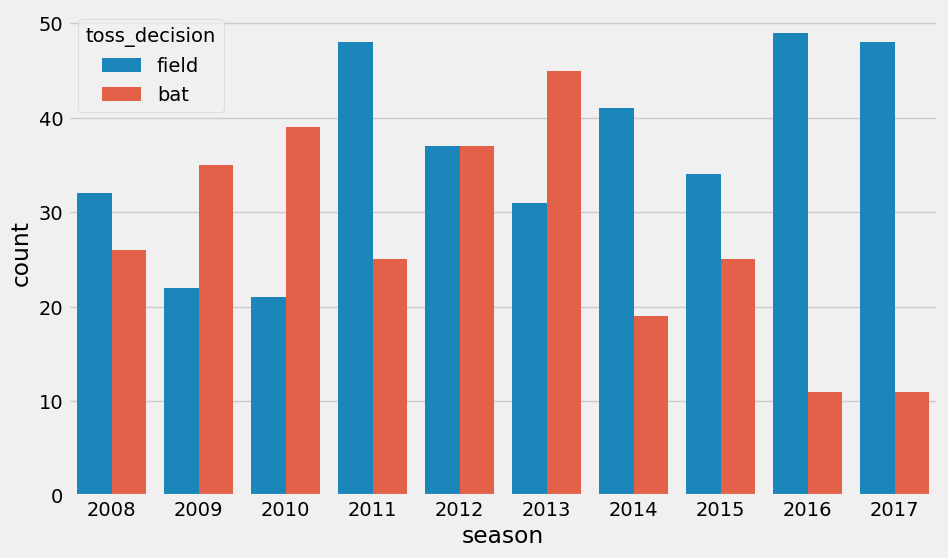

In [18]:
mlt.subplots(figsize = (10, 6))
sns.countplot(x = 'season', hue = 'toss_decision', data = matches)
mlt.show()

## Max Toss Winners


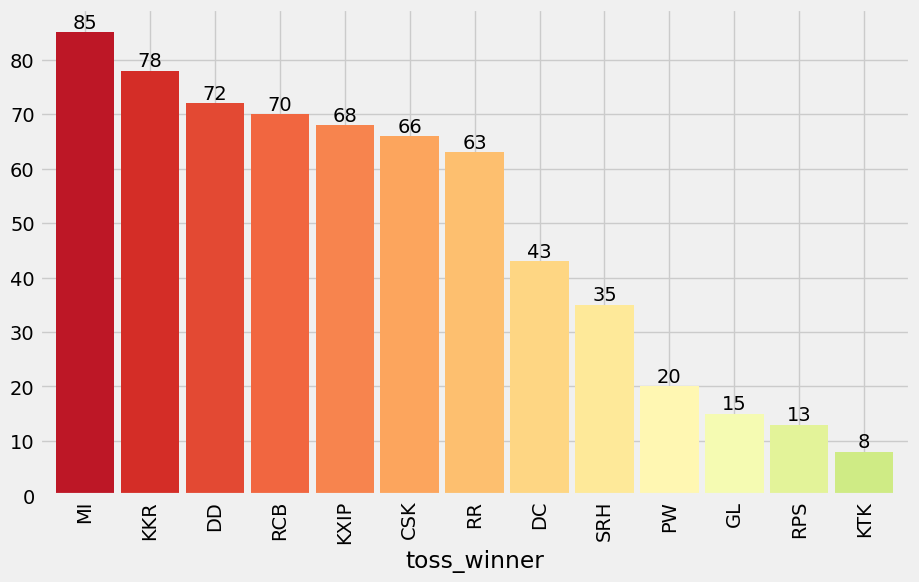

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplots(figsize=(10, 6))

ax = matches['toss_winner'].value_counts().plot(
    kind='bar',
    width=0.9,
    color=sns.color_palette('RdYlGn', 20)
)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
    )

plt.show()

## Total Matches vs Wins for Teams

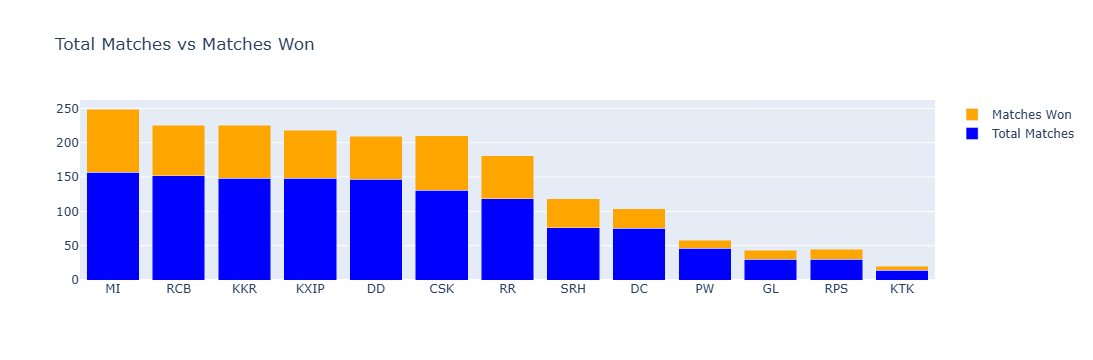

In [20]:
import plotly.graph_objs as go
import plotly.offline as py

# Total matches played by each team
matches_played_byteams = pd.concat([matches['team1'], matches['team2']])
matches_played_byteams = matches_played_byteams.value_counts().reset_index()
matches_played_byteams.columns = ['Team', 'Total Matches']

# Total wins by each team
wins = matches['winner'].value_counts().reset_index()
wins.columns = ['Team', 'wins']

# Merge total matches and wins
matches_played_byteams = pd.merge(matches_played_byteams, wins, on='Team', how='left')

# If any team has no wins, fill with 0
matches_played_byteams['wins'] = matches_played_byteams['wins'].fillna(0)

# Set Team as index
matches_played_byteams.set_index('Team', inplace=True)

# Total Matches Bar
trace1 = go.Bar(
    x = matches_played_byteams.index,
    y = matches_played_byteams['Total Matches'],
    name = 'Total Matches',
    marker=dict(color='blue')
)

# Matches Won Bar
trace2 = go.Bar(
    x = matches_played_byteams.index,
    y = matches_played_byteams['wins'],
    name = 'Matches Won',
    marker=dict(color='orange')
)

data = [trace1, trace2]

layout = go.Layout(
    title='Total Matches vs Matches Won',
    barmode='stack'
)

fig = go.Figure(data=data, layout=layout)

py.iplot(fig)

      Total Matches  wins
Team                     
MI              157    92
RCB             152    73
KKR             148    77
KXIP            148    70
DD              147    62
CSK             131    79
RR              118    63
SRH              76    42
DC               75    29
PW               46    12
GL               30    13
RPS              30    15
KTK              14     6


C:\Users\acer\AppData\Local\Temp\ipykernel_14920\477453479.py:12: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





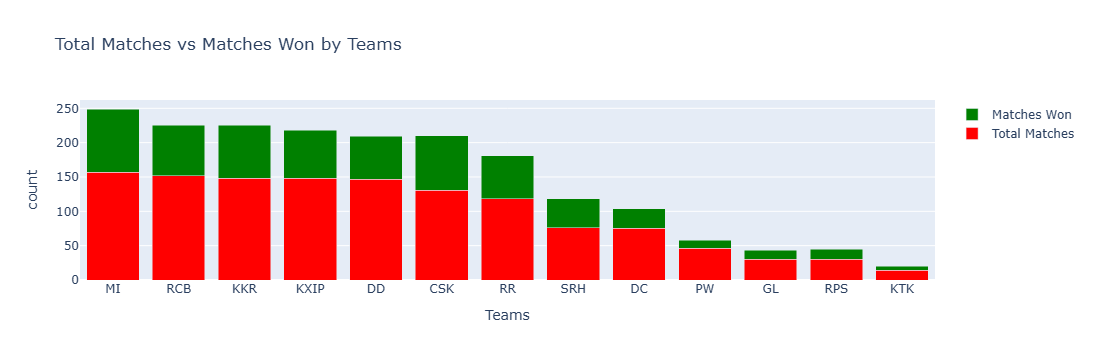

In [21]:
py.init_notebook_mode(connected=True)

matches_played_byteams = pd.concat([matches['team1'], matches['team2']])

matches_played_byteams = matches_played_byteams.value_counts().reset_index()
matches_played_byteams.columns = ['Team', 'Total Matches']

wins = matches['winner'].value_counts().reset_index()
wins.columns = ['Team', 'wins']

matches_played_byteams = matches_played_byteams.merge(wins, on='Team', how='left')
matches_played_byteams['wins'].fillna(0, inplace=True)  #Handle teams with on wins

matches_played_byteams.set_index('Team', inplace=True)

#Debug: Check the DataFrame Structure
print(matches_played_byteams)

#Step 6: create stacked bar chart
trace1 = go.Bar(
    x = matches_played_byteams.index,
    y = matches_played_byteams['Total Matches'],
    name = 'Total Matches',
    marker=dict(color='red')
)

trace2 = go.Bar(
    x = matches_played_byteams.index,
    y = matches_played_byteams['wins'],
    name = 'Matches Won',
    marker=dict(color='green')
)

data = [trace1, trace2]
layout = go.Layout(
    title='Total Matches vs Matches Won by Teams',
    xaxis=dict(title='Teams'),
    yaxis=dict(title='count'),
    barmode='stack'
)

fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='stacked-bar')

## Is Toss Winner also the match winner

In [22]:
matches.shape

(636, 17)

In [23]:
len(df)

1

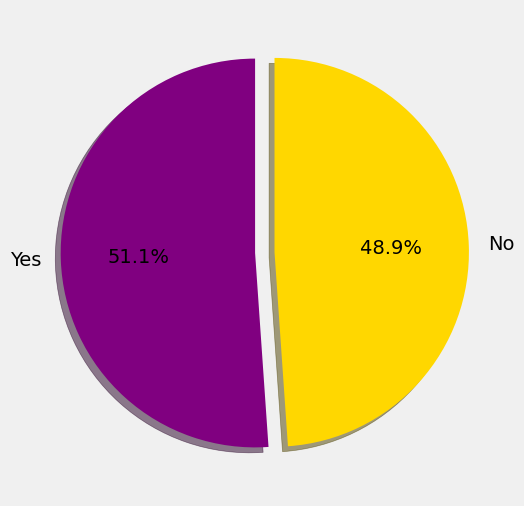

In [24]:
df = matches[matches['toss_winner'] == matches['winner']]

slices = [len(df), 636 - len(df)]

labels = ['Yes', 'No']

plt.pie(
    slices,
    labels=labels,
    startangle=90,
    shadow=True,
    explode=(0, 0.1),
    autopct="%.1f%%",
    colors=['purple', 'gold'])

fig = plt.gcf()
fig.set_size_inches(6, 6)

plt.show()

## Matches played across each season

C:\Users\acer\AppData\Local\Temp\ipykernel_14920\3383703.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\acer\AppData\Local\Temp\ipykernel_14920\3383703.py:3: UserWarning:


The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.



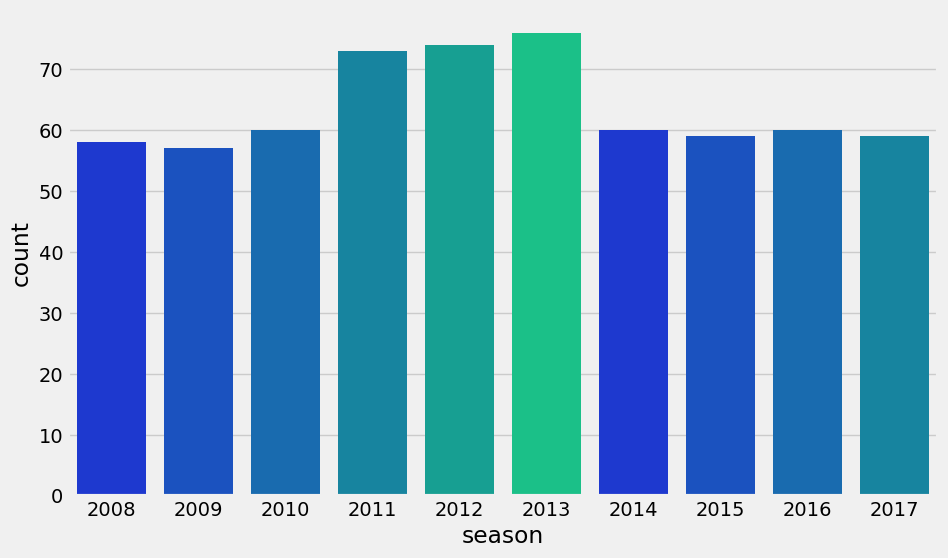

In [25]:
mlt.subplots(figsize = (10, 6))

sns.countplot(x = 'season', data = matches, palette = sns.color_palette("winter"))

mlt.show()

## Runs Across the Seasons

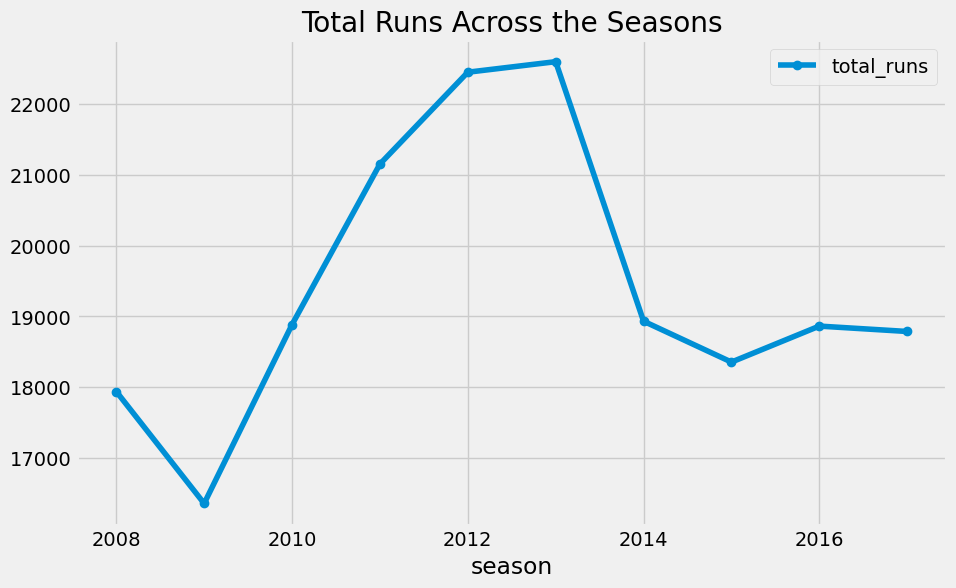

In [26]:
batsmen = matches[['id', 'season']].merge(
    delivery,
    left_on='id',
    right_on='match_id',
    how='left').drop('id', axis=1)

season = batsmen.groupby('season')['total_runs'].sum().reset_index()

season.set_index('season').plot(marker='o')

plt.gcf().set_size_inches(10, 6)

plt.title("Total Runs Across the Seasons")

plt.show()

## Average runs per match season

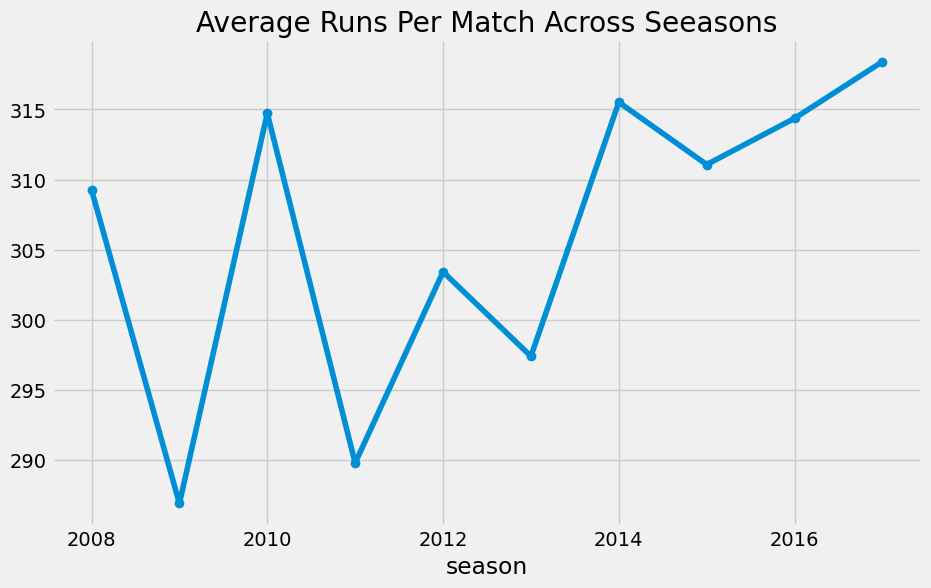

In [27]:
avgruns_each_season = matches.groupby(['season']).count().id.reset_index()

avgruns_each_season.rename(columns = {'id':'matches'}, inplace = True)

avgruns_each_season['total_runs'] = season['total_runs']

avgruns_each_season['average_runs_per_match'] = avgruns_each_season['total_runs'] / avgruns_each_season['matches']

avgruns_each_season.set_index('season')['average_runs_per_match'].plot(marker = 'o')

mlt.gcf().set_size_inches(10, 6)

mlt.title('Average Runs Per Match Across Seeasons')

mlt.show()

## Sixes and Fours Across the Season

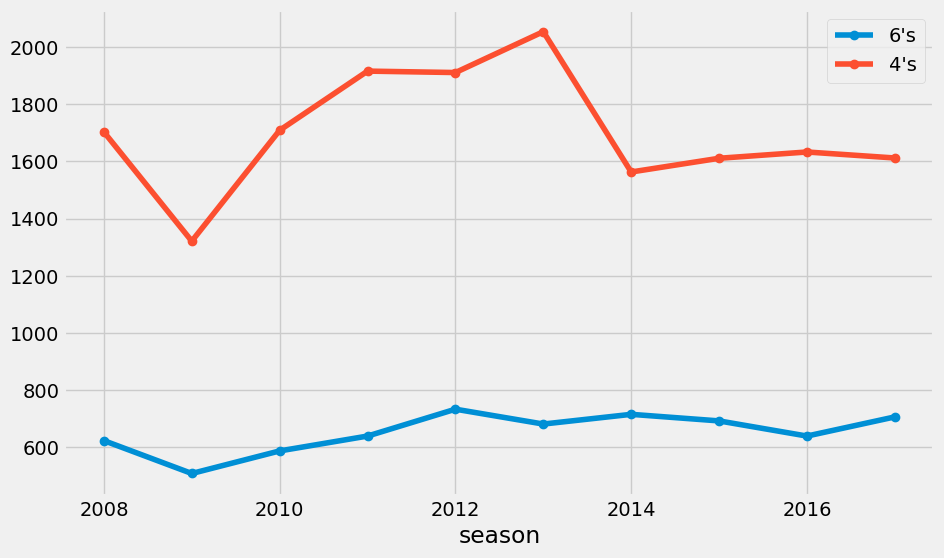

In [28]:
season_boundaries = batsmen.groupby("season")['batsman_runs'].agg(lambda x: (x == 6).sum()).reset_index()

a = batsmen.groupby("season")['batsman_runs'].agg(lambda x: (x == 4).sum()).reset_index()

season_boundaries = season_boundaries.merge(a, on='season', how='left')

season_boundaries.rename(
    columns={'batsman_runs_x': "6's", 'batsman_runs_y': "4's"},
    inplace=True
)

season_boundaries.set_index('season')[["6's", "4's"]].plot(marker='o')

plt.gcf().set_size_inches(10, 6)
plt.show()

## Runs Per Over By Teams Across Seasons

C:\Users\acer\AppData\Local\Temp\ipykernel_14920\730105461.py:1: FutureWarning:

The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.



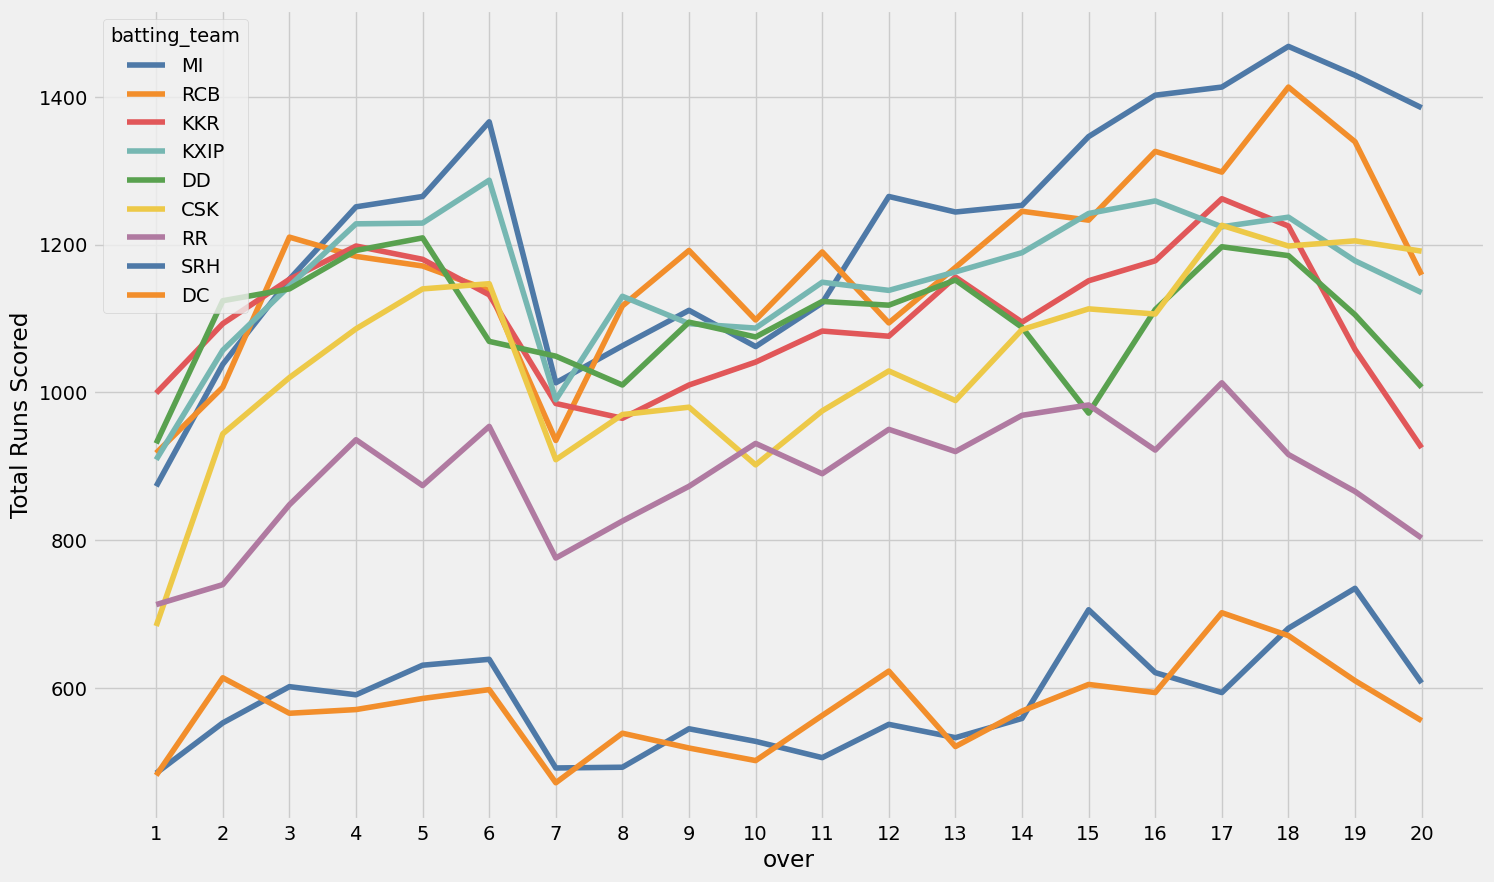

In [29]:
runs_per_over = delivery.pivot_table(
    index='over',
    columns='batting_team',
    values='total_runs',
    aggfunc=sum
)

runs_per_over[
    matches_played_byteams[matches_played_byteams['Total Matches'] > 50].index
].plot(
    color=['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F',
           '#EDC948', '#B07AA1']
)

x = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]

plt.xticks(x)

plt.ylabel('Total Runs Scored')

fig = plt.gcf()

fig.set_size_inches(16, 10)

plt.show()

## Favorite Grounds

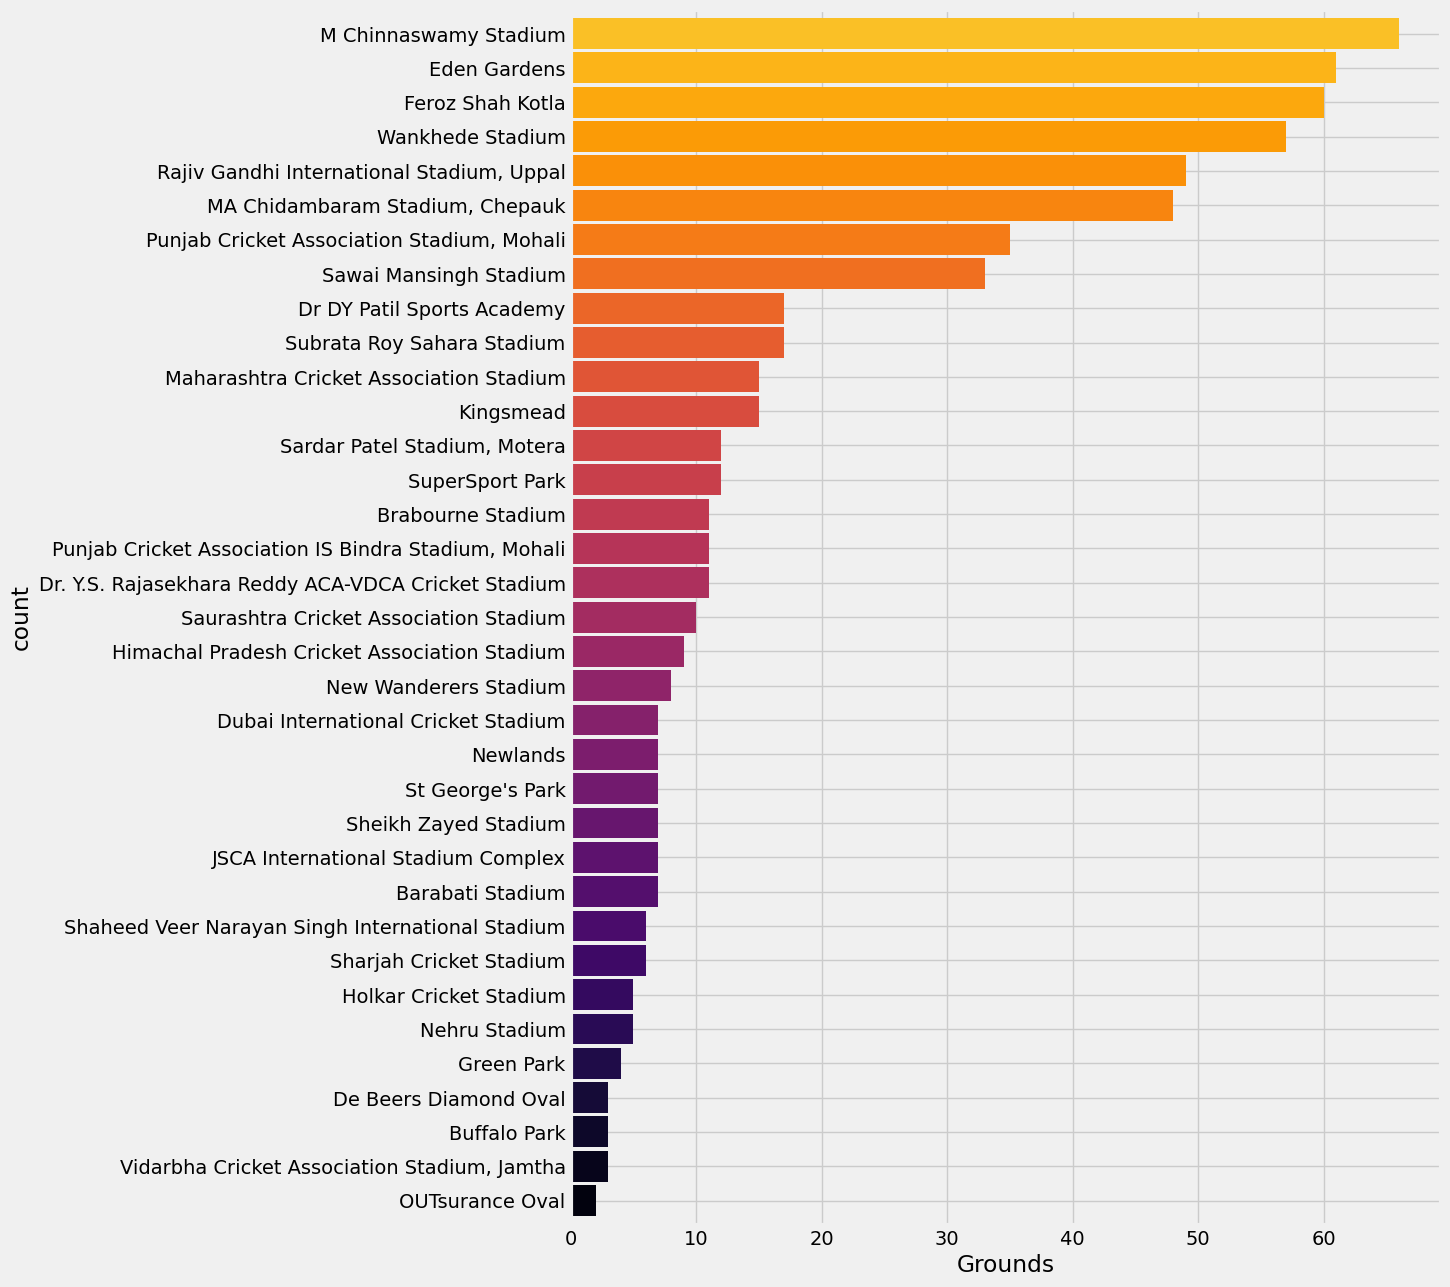

In [30]:
mlt.subplots(figsize = (10, 15))

ax = matches['venue'].value_counts().sort_values(ascending = True).plot.barh(width = 0.9, color = sns.color_palette('inferno', 40))

ax.set_xlabel('Grounds')

ax.set_ylabel('count')

mlt.show()

## Maximum Man of Matches

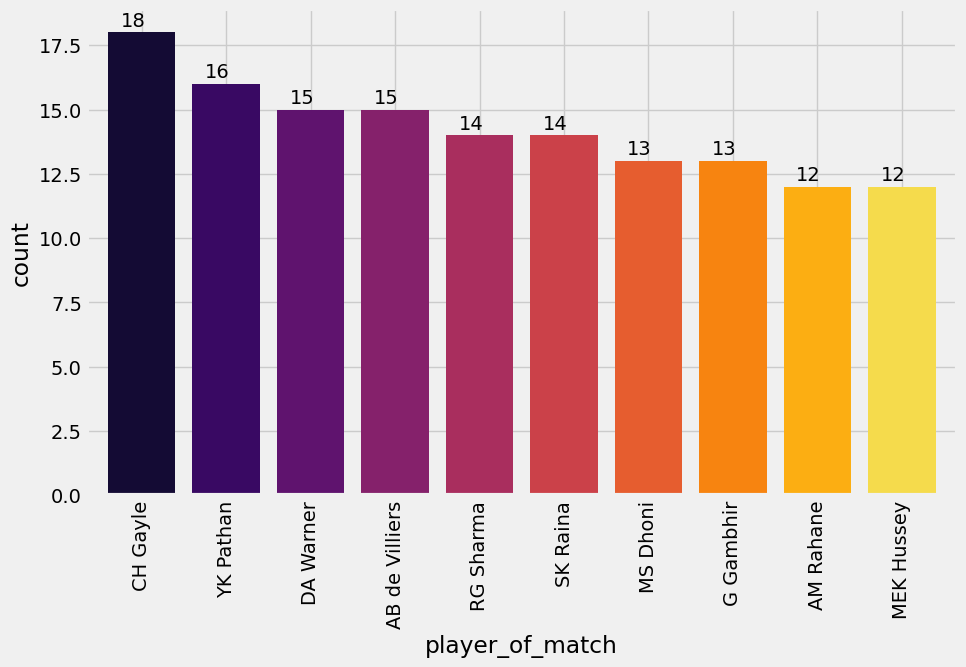

In [31]:
mlt.subplots(figsize = (10, 6))

ax = matches['player_of_match'].value_counts().head(10).plot.bar(width = 0.8, color = sns.color_palette('inferno', 10))

ax.set_xlabel('player_of_match')

ax.set_ylabel('count')

for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.15, p.get_height() + 0.25))

mlt.show()    

## Winner by Year

In [32]:
print('Winner By Years:\n')

for i in range(2008, 2017):
    df = ((matches[matches['season'] == i]).iloc[-1])
    print(df[[1, 10]].values)

Winner By Years:

[np.int64(2008) 'RR']
[np.int64(2009) 'DC']
[np.int64(2010) 'CSK']
[np.int64(2011) 'CSK']
[np.int64(2012) 'KKR']
[np.int64(2013) 'MI']
[np.int64(2014) 'KKR']
[np.int64(2015) 'MI']
[np.int64(2016) 'SRH']


C:\Users\acer\AppData\Local\Temp\ipykernel_14920\1635098425.py:5: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



## Super Over

In [33]:
print("\n Total Matches with Super Overs:", delivery[delivery['is_super_over'] == 1].match_id.nunique())


 Total Matches with Super Overs: 7


In [34]:
teams = ['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR', 'DD', 'GL', 'KXIP', 'SRH', 'RPS', 'KTK', 'PW']

play = delivery[delivery['is_super_over'] == 1].batting_team.unique()
play = list(play)

print("Teams who haven't ever played a super over are:",
      [team for team in teams if team not in play])

Teams who haven't ever played a super over are: ['DC', 'RPS', 'KTK', 'PW']


## Favorite Umpires:

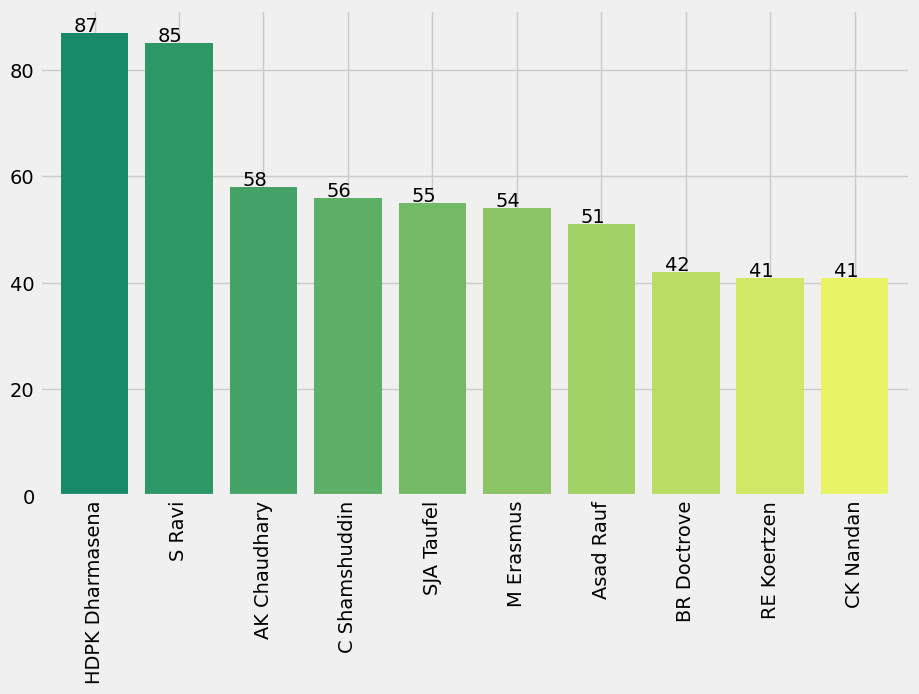

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

ump = pd.concat([matches['umpire1'], matches['umpire2']])

ump.value_counts().head(10).plot.bar(
    width=0.8,
    color=sns.color_palette('summer', 10),
    ax=ax
)

for p in ax.patches:
    ax.annotate(
        format(p.get_height()),
        (p.get_x() + 0.15, p.get_height() + 0.25)
    )

plt.show()

## Team1 vs Tame2

### MI vs KKR

In [36]:
def team1_vs_team2(team1, team2):
    mt1 = matches[
        ((matches['team1'] == team1) | (matches['team2'] == team1)) &
        ((matches['team1'] == team2) | (matches['team2'] == team2))
    ]

    sns.countplot(x='season', hue='winner', data=mt1, palette='Set3')

    plt.xticks(rotation='vertical')
    plt.legend(loc='upper center')

    fig = plt.gcf()
    fig.set_size_inches(10, 6)

    plt.show()

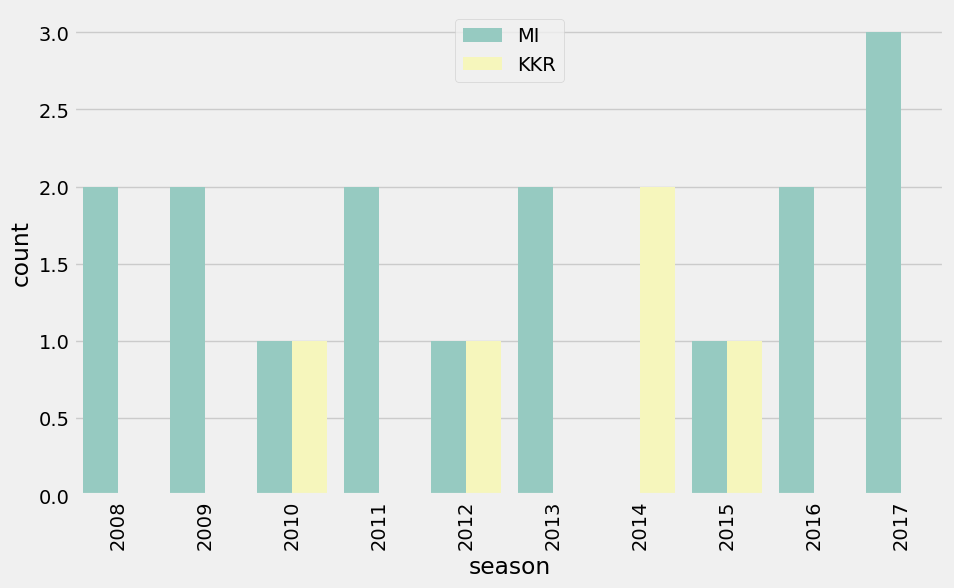

In [37]:
team1_vs_team2('KKR', 'MI')

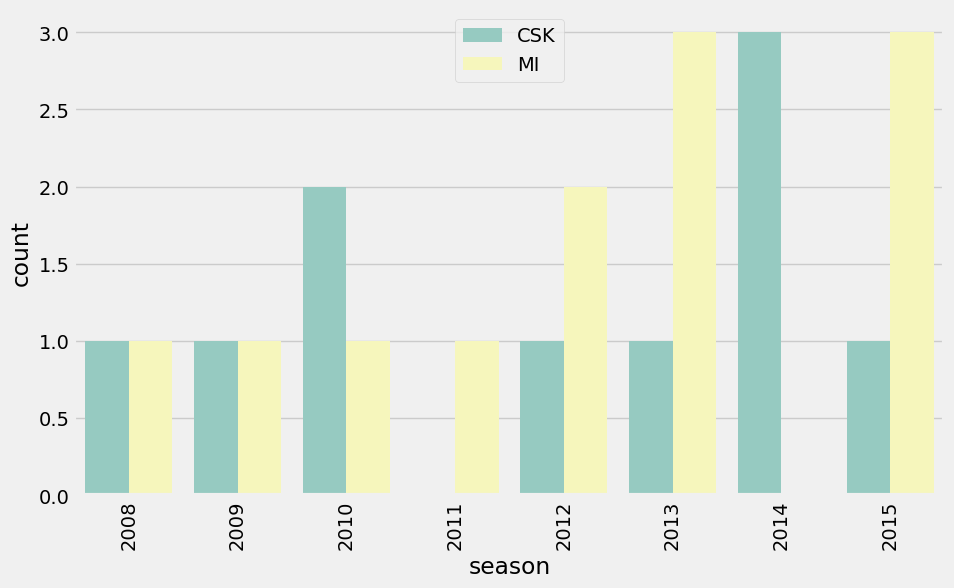

In [38]:
team1_vs_team2('CSK', 'MI')

## Matches Won By a Team Against Other Teams


In [39]:
def comparator(team1):
    teams = ['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR', 'DD', 'GL', 'KXIP', 'SPH', 'RPS', 'KTK', 'PW']
    teams.remove(team1)
    opponents = teams.copy()
    mt1 = matches[((matches['team1'] == team1) | (matches['team2'] == team1))]
    for i in opponents:
        mask = (((mt1['team1'] == i) | (mt1['team2'] == i))) & ((mt1['team1'] == team1) | (mt1['team2']) == team1)
        mt2 = mt1.loc[mask, 'winner'].value_counts().to_frame().T
        print(mt2)

In [40]:
comparator('MI')

Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]
Empty DataFrame
Columns: []
Index: [count]


## Score Distribution For Teams by Innings

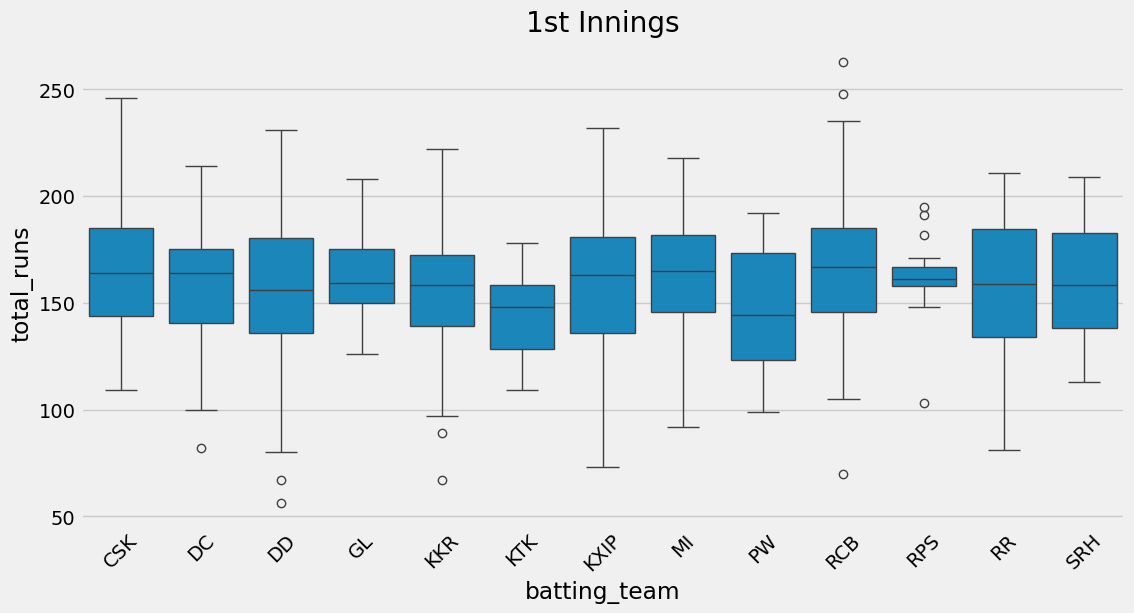

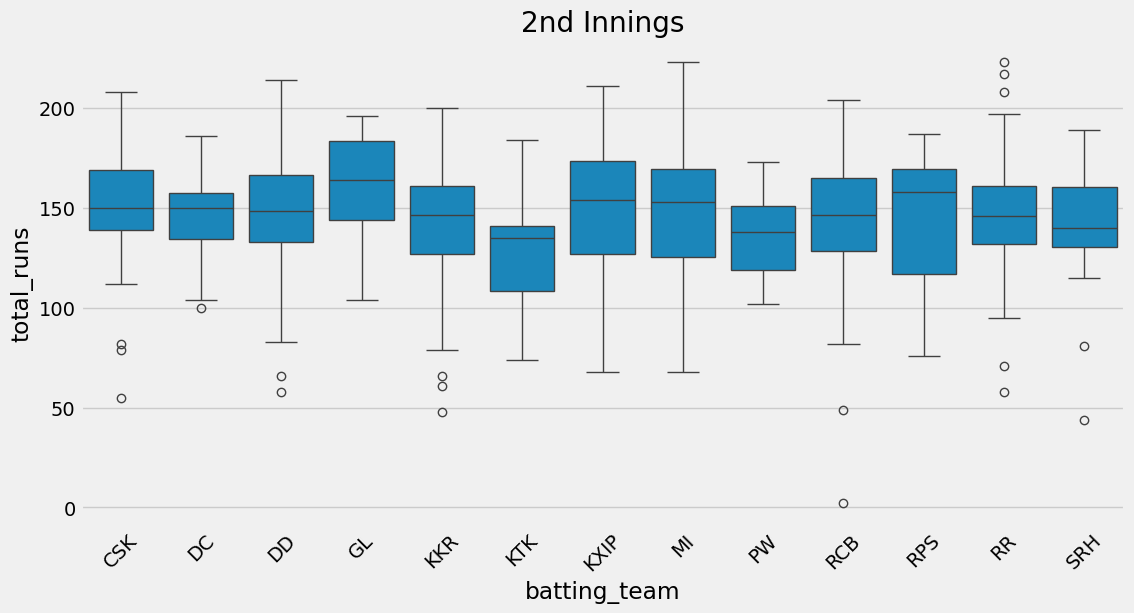

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

xyz = delivery.groupby(
    ['match_id', 'inning', 'batting_team']
)['total_runs'].sum().reset_index()

xyz.drop('match_id', axis=1, inplace=True)

xyz = xyz.sort_values(
    by=['batting_team', 'total_runs'],
    ascending=True
)

score_1_inning = xyz[xyz['inning'] == 1]
score_2_inning = xyz[xyz['inning'] == 2]

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='batting_team',
    y='total_runs',
    data=score_1_inning
)
plt.title('1st Innings')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='batting_team',
    y='total_runs',
    data=score_2_inning
)
plt.title('2nd Innings')
plt.xticks(rotation=45)
plt.show()


## 200+Scores

In [42]:
high_scores = delivery.groupby(['match_id', 'inning', 'batting_team', 'bowling_team'])['total_runs'].sum().reset_index()

high_scores = high_scores[high_scores['total_runs'] >=200]

high_scores.nlargest(10, 'total_runs')

,match_id,inning,batting_team,bowling_team,total_runs
829,411,1,RCB,PW,263
1250,620,1,RCB,GL,248
416,206,1,CSK,RR,246
122,61,1,CSK,KXIP,240
1134,562,1,RCB,MI,235
596,296,1,KXIP,RCB,232
522,259,1,DD,KXIP,231
981,486,1,KXIP,CSK,231
100,50,1,KXIP,MI,230
1170,580,1,RCB,SRH,227


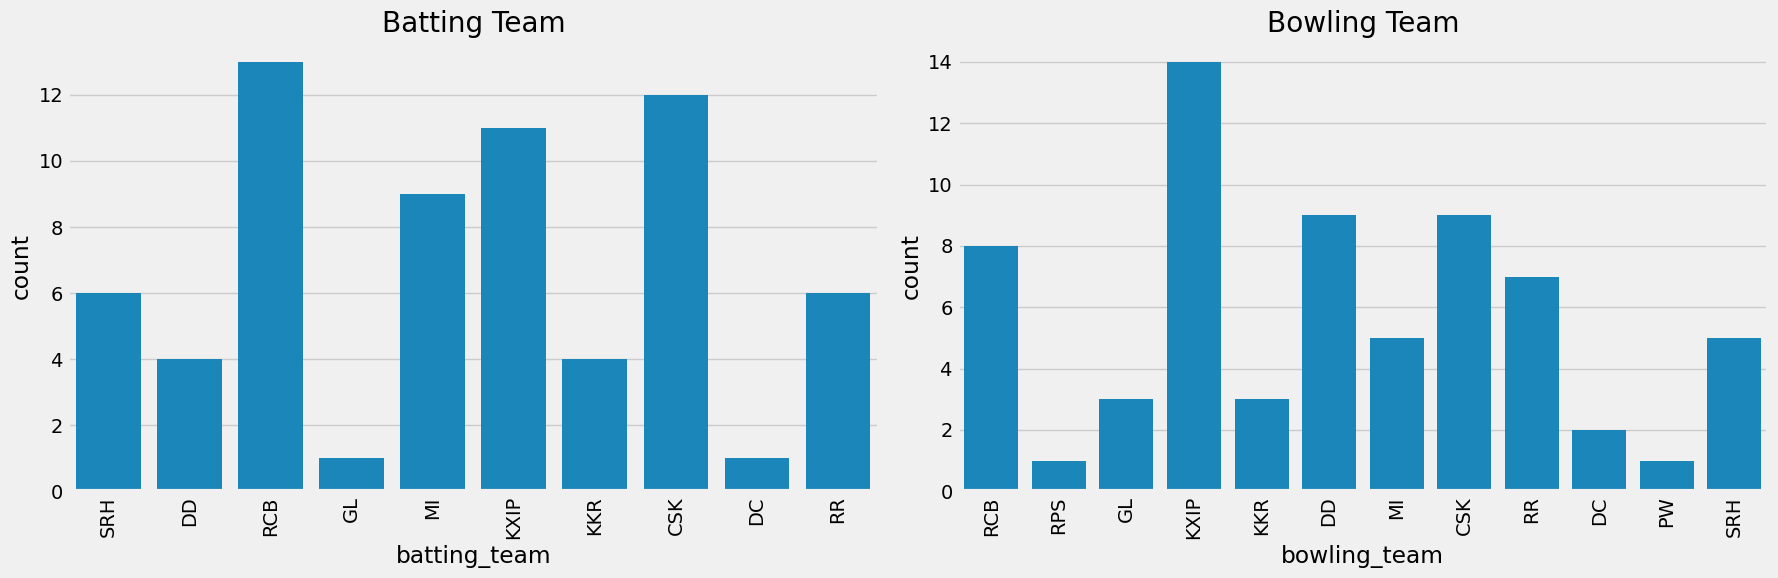

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(
    x='batting_team',
    data=high_scores,
    ax=ax[0]
)
ax[0].set_title('Batting Team')
ax[0].tick_params(axis='x', rotation=90)

sns.countplot(
    x='bowling_team',
    data=high_scores,
    ax=ax[1]
)
ax[1].set_title('Bowling Team')
ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


In [44]:
print("Teams who have not ever scored 200+ runs:", list(set(teams) - set(high_scores['batting_team'])))

print("Teams who have not conceeded over 200+ runs:", list(set(teams) - set(high_scores['bowling_team'])))


Teams who have not ever scored 200+ runs: ['KTK', 'PW', 'RPS']
Teams who have not conceeded over 200+ runs: ['KTK']


In [45]:
high = delivery.groupby(['match_id', 'inning', 'batting_team', 'bowling_team'])['total_runs'].sum().reset_index()

high.set_index(['match_id'], inplace = True)

high['total_runs'].max()

high = high.rename(columns = {'total_runs': 'count'})

high = high[high['count'] >=200].groupby(['inning', 'batting_team', 'bowling_team']).count()

high

count
inning batting_team bowling_team       
1      CSK          DD                1
                    KKR               1
                    KXIP              2
                    MI                1
                    RCB               1
                    RR                1
                    SRH               2
       DC           RR                1
       DD           KXIP              1
                    MI                1
                    RPS               1
       GL           DD                1
       KKR          DC                1
                    KXIP              1
                    RCB               1
       KXIP         CSK               2
                    MI                1
                    RCB               2
                    RR                1
       MI           CSK               1
                    DD                4
                    RCB               1
                    RR                1
       RCB          CSK               1
                    DD                1
                    GL                2
                    KXIP              3
                    MI                1
                    PW                1
                    RR                1
                    SRH               1
       RR           CSK               1
                    DD                1
                    KXIP              1
       SRH          KKR               1
                    KXIP              2
                    RCB               2
                    RR                1
2      CSK          KXIP              1
                    RCB               1
                    RR                1
       DD           GL                1
       KKR          KXIP              1
       KXIP         CSK               2
                    DD                1
                    KKR               1
                    SRH               1
       MI           CSK               1
                    KXIP              1
       RCB          KXIP              1
                    SRH               1
       RR           CSK               1
                    DC                1
                    MI                1

In [46]:
high_scores = delivery.groupby(
    ['match_id', 'inning', 'batting_team', 'bowling_team']
)['total_runs'].sum().reset_index()

high_scores1 = high_scores[high_scores['inning'] == 1]
high_scores2 = high_scores[high_scores['inning'] == 2]

high_scores1 = high_scores1.merge(
    high_scores2[['match_id', 'inning', 'total_runs']],
    on='match_id'
)

high_scores1.rename(
    columns={
        'inning_x': 'inning_1',
        'inning_y': 'inning_2',
        'total_runs_x': 'inning1_runs',
        'total_runs_y': 'inning2_runs'
    },
    inplace=True
)

high_scores1 = high_scores1[
    high_scores1['inning1_runs'] >= 200
]

high_scores1['is_score_chased'] = np.where(
    high_scores1['inning1_runs'] <= high_scores1['inning2_runs'],
    'yes',
    'no'
)

high_scores1.head()

,match_id,inning_1,batting_team,bowling_team,inning1_runs,inning_2,inning2_runs,is_score_chased
0,1,1,SRH,RCB,207,2,172,no
8,9,1,DD,RPS,205,2,108,no
19,20,1,RCB,GL,213,2,192,no
31,32,1,SRH,KXIP,207,2,181,no
35,36,1,SRH,KKR,209,2,161,no


## Chances of Chasing 200 + Target

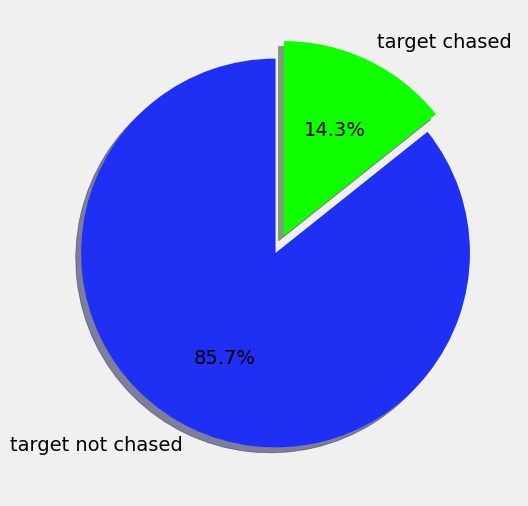

In [47]:
slices = high_scores1['is_score_chased'].map({
    'yes': 1,
    'no': 0
}).value_counts()

labels = ['target not chased', 'target chased']

mlt.pie(
    slices,
    labels=labels,
    colors=['#1f2ff3', '#0fff00'],
    startangle=90,
    shadow=True,
    explode=(0, 0.1),
    autopct='%1.1f%%'
)

fig = mlt.gcf()
fig.set_size_inches(6, 6)

mlt.show()

## Bastman Comparator

In [48]:
balls = delivery.groupby(['batsman'])['ball'].count().reset_index()

In [49]:
runs = delivery.groupby(['batsman'])['batsman_runs'].sum().reset_index()

In [50]:
balls = balls.merge(runs, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [51]:
balls.rename({"ball": "ball_x", "batsman_runs": "ball_y"}, axis = 1, inplace = True)

In [52]:
fours = delivery.groupby('batsman')['batsman_runs'].agg(lambda x: (x == 4).sum()).reset_index()

In [53]:
sixes = delivery.groupby('batsman')['batsman_runs'].agg(lambda x: (x == 6).sum()).reset_index()

In [54]:
balls['ball_y'] / balls['ball_x']*100

0      142.857143
1       57.142857
2       70.666667
3      125.000000
4      108.771930
          ...    
456    104.918033
457     70.149254
458     42.857143
459    126.390244
460     82.978723
Length: 461, dtype: float64

In [55]:
balls['strike_rate'] = balls['ball_y'] / balls['ball_x']*100

In [56]:
ball = balls.merge(sixes, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [57]:
balls = balls.merge(fours, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [58]:
compare = delivery.groupby(['match_id', 'batsman', 'batting_team'])['batsman_runs'].sum().reset_index()

In [59]:
compare = compare.groupby(['batsman', 'batting_team'])['batsman_runs'].max()

In [60]:
balls = balls.merge(compare, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [61]:
ball.rename({'ball_x':'balls', "ball_y": 'runs', 'batsman_runs_x': "6's", "batsman_runs_y": "4's", 'batting_team':"Team", "batsman_runs": "Highest_score"}, axis = 1, inplace = True)

In [62]:
balls.head()

,batsman,ball_x,ball_y,strike_rate,batsman_runs_x,batsman_runs_y
0,A Ashish Reddy,196,280,142.857143,16,10
1,A Ashish Reddy,196,280,142.857143,16,36
2,A Chandila,7,4,57.142857,0,4
3,A Chopra,75,53,70.666667,7,24
4,A Choudhary,20,25,125.000000,1,15


In [63]:
balls.tail()

,batsman,ball_x,ball_y,strike_rate,batsman_runs_x,batsman_runs_y
778,Yuvraj Singh,2050,2591,126.390244,205,83
779,Yuvraj Singh,2050,2591,126.390244,205,70
780,Z Khan,141,117,82.978723,11,4
781,Z Khan,141,117,82.978723,11,23
782,Z Khan,141,117,82.978723,11,21


In [64]:
balls

,batsman,ball_x,ball_y,strike_rate,batsman_runs_x,batsman_runs_y
0,A Ashish Reddy,196,280,142.857143,16,10
1,A Ashish Reddy,196,280,142.857143,16,36
2,A Chandila,7,4,57.142857,0,4
3,A Chopra,75,53,70.666667,7,24
4,A Choudhary,20,25,125.000000,1,15
...,...,...,...,...,...,...
778,Yuvraj Singh,2050,2591,126.390244,205,83
779,Yuvraj Singh,2050,2591,126.390244,205,70
780,Z Khan,141,117,82.978723,11,4
781,Z Khan,141,117,82.978723,11,23


In [65]:
print(balls.columns.tolist())

['batsman', 'ball_x', 'ball_y', 'strike_rate', 'batsman_runs_x', 'batsman_runs_y']


In [66]:
import matplotlib.pyplot as plt

def batsman_comparator(stat1, stat2, batsman1, batsman2):

    # Create 4s and 6s
    balls['4s'] = (balls['batsman_runs_x'] == 4).astype(int)
    balls['6s'] = (balls['batsman_runs_x'] == 6).astype(int)

    # Calculate total 4s and 6s for each batsman
    bats_stats = balls.groupby('batsman')[['4s', '6s']].sum().reset_index()

    # Select batsmen
    bats1 = bats_stats[
        bats_stats['batsman'].str.contains(batsman1, case=False, na=False)
    ]

    bats2 = bats_stats[
        bats_stats['batsman'].str.contains(batsman2, case=False, na=False)
    ]

    # Check if batsmen exist
    if bats1.empty:
        print("Batsman not found:", batsman1)
        return

    if bats2.empty:
        print("Batsman not found:", batsman2)
        return

    # Plot
    plt.figure(figsize=(15, 10))

    plt.scatter(
        bats1[stat1],
        bats1[stat2],
        s=150,
        c='green'
    )

    plt.scatter(
        bats2[stat1],
        bats2[stat2],
        s=150,
        c='red'
    )

    # Labels
    plt.text(
        bats1[stat1].iloc[0],
        bats1[stat2].iloc[0],
        batsman1,
        fontsize=12,
        weight='bold'
    )

    plt.text(
        bats2[stat1].iloc[0],
        bats2[stat2].iloc[0],
        batsman2,
        fontsize=12,
        weight='bold'
    )

    plt.xlabel("Number of 4s")
    plt.ylabel("Number of 6s")
    plt.title("Batsman Comparator", fontsize=25)
    plt.grid(alpha=0.3)
    plt.show()

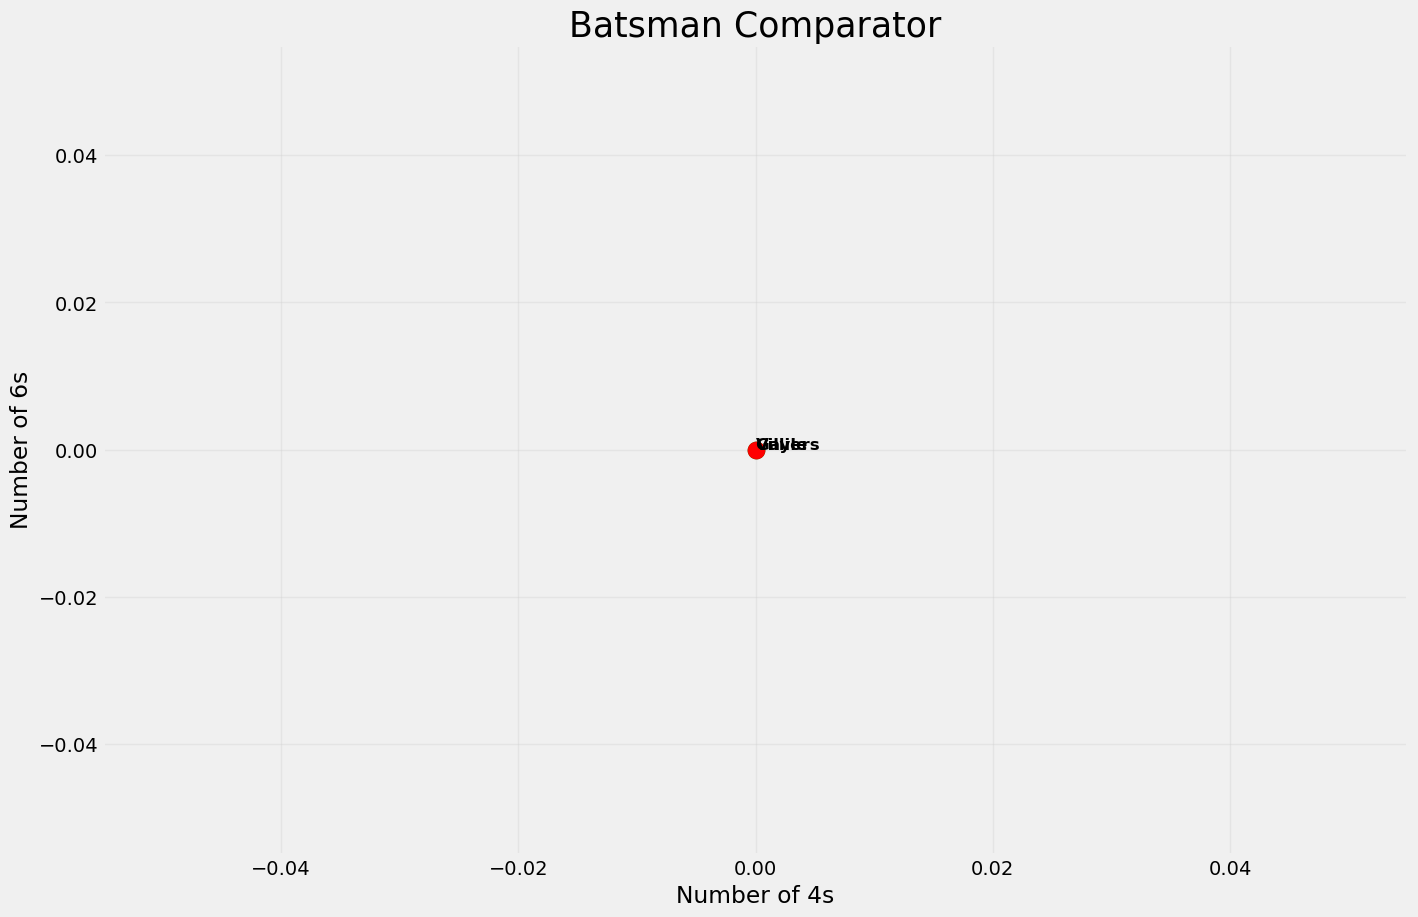

In [67]:
batsman_comparator('4s', '6s', 'Gayle', 'Villiers')

In [68]:
import matplotlib.pyplot as plt

def batsman_comparator(batsman1, batsman2):

    # Calculate total runs and average strike rate
    bats_stats = balls.groupby('batsman').agg(
        runs=('batsman_runs_x', 'sum'),
        strike_rate=('strike_rate', 'mean')
    ).reset_index()

    # Select batsmen
    bats1 = bats_stats[
        bats_stats['batsman'].str.contains(batsman1, case=False, na=False)
    ]

    bats2 = bats_stats[
        bats_stats['batsman'].str.contains(batsman2, case=False, na=False)
    ]

    # Check batsmen
    if bats1.empty:
        print("Batsman not found:", batsman1)
        return

    if bats2.empty:
        print("Batsman not found:", batsman2)
        return

    # Plot
    plt.figure(figsize=(15, 10))

    plt.scatter(
        bats1['runs'],
        bats1['strike_rate'],
        s=150,
        c='green'
    )

    plt.scatter(
        bats2['runs'],
        bats2['strike_rate'],
        s=150,
        c='red'
    )

    # Labels
    plt.text(
        bats1['runs'].iloc[0],
        bats1['strike_rate'].iloc[0],
        batsman1,
        fontsize=12,
        weight='bold'
    )

    plt.text(
        bats2['runs'].iloc[0],
        bats2['strike_rate'].iloc[0],
        batsman2,
        fontsize=12,
        weight='bold'
    )

    plt.xlabel("Runs")
    plt.ylabel("Strike Rate")
    plt.title("Batsman Comparator", fontsize=25)
    plt.grid(alpha=0.3)

    plt.show()

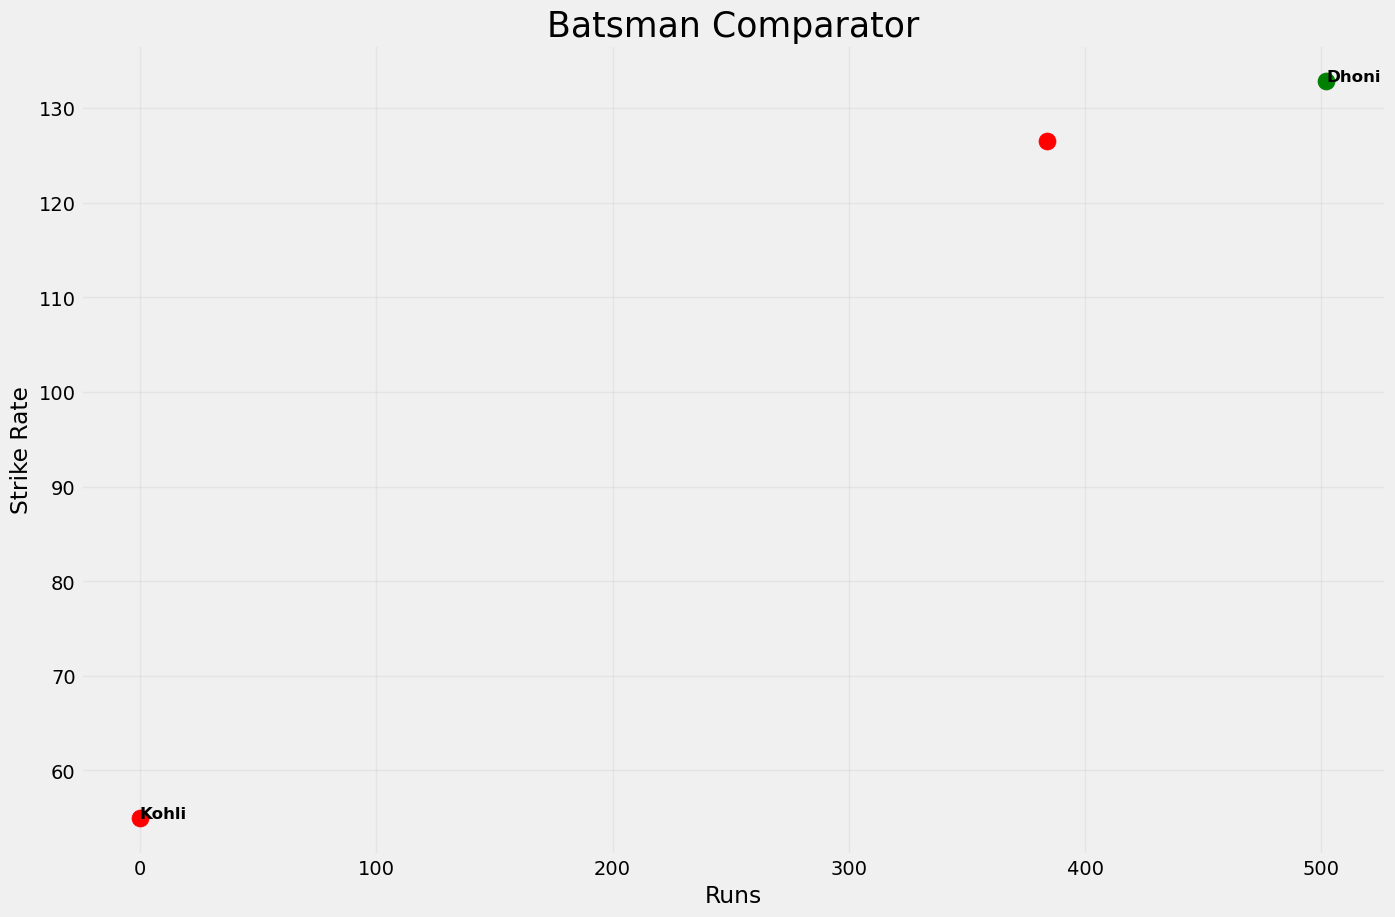

In [69]:
batsman_comparator("Dhoni", "Kohli")

## Top 10 Batsman

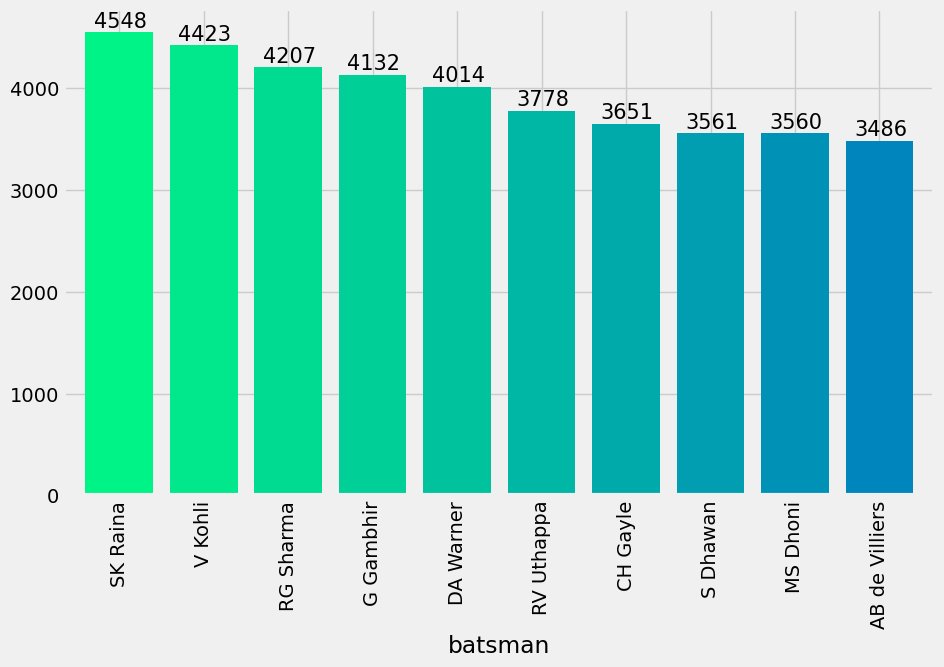

In [70]:
mlt.subplots(figsize = (10, 6))

max_runs = delivery.groupby(['batsman'])['batsman_runs'].sum()

ax = max_runs.sort_values(ascending = False)[:10].plot.bar(width = 0.8, color = sns.color_palette("winter_r", 20))

for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.1, p.get_height() + 50), fontsize = 15)

mlt.show()    

In [71]:
max_runs

batsman
A Ashish Reddy     280
A Chandila           4
A Chopra            53
A Choudhary         25
A Flintoff          62
                  ... 
YV Takawale        192
Yashpal Singh       47
Younis Khan          3
Yuvraj Singh      2591
Z Khan             117
Name: batsman_runs, Length: 461, dtype: int64

## Top Batsman's with 1's, 2's, 3's, 4's

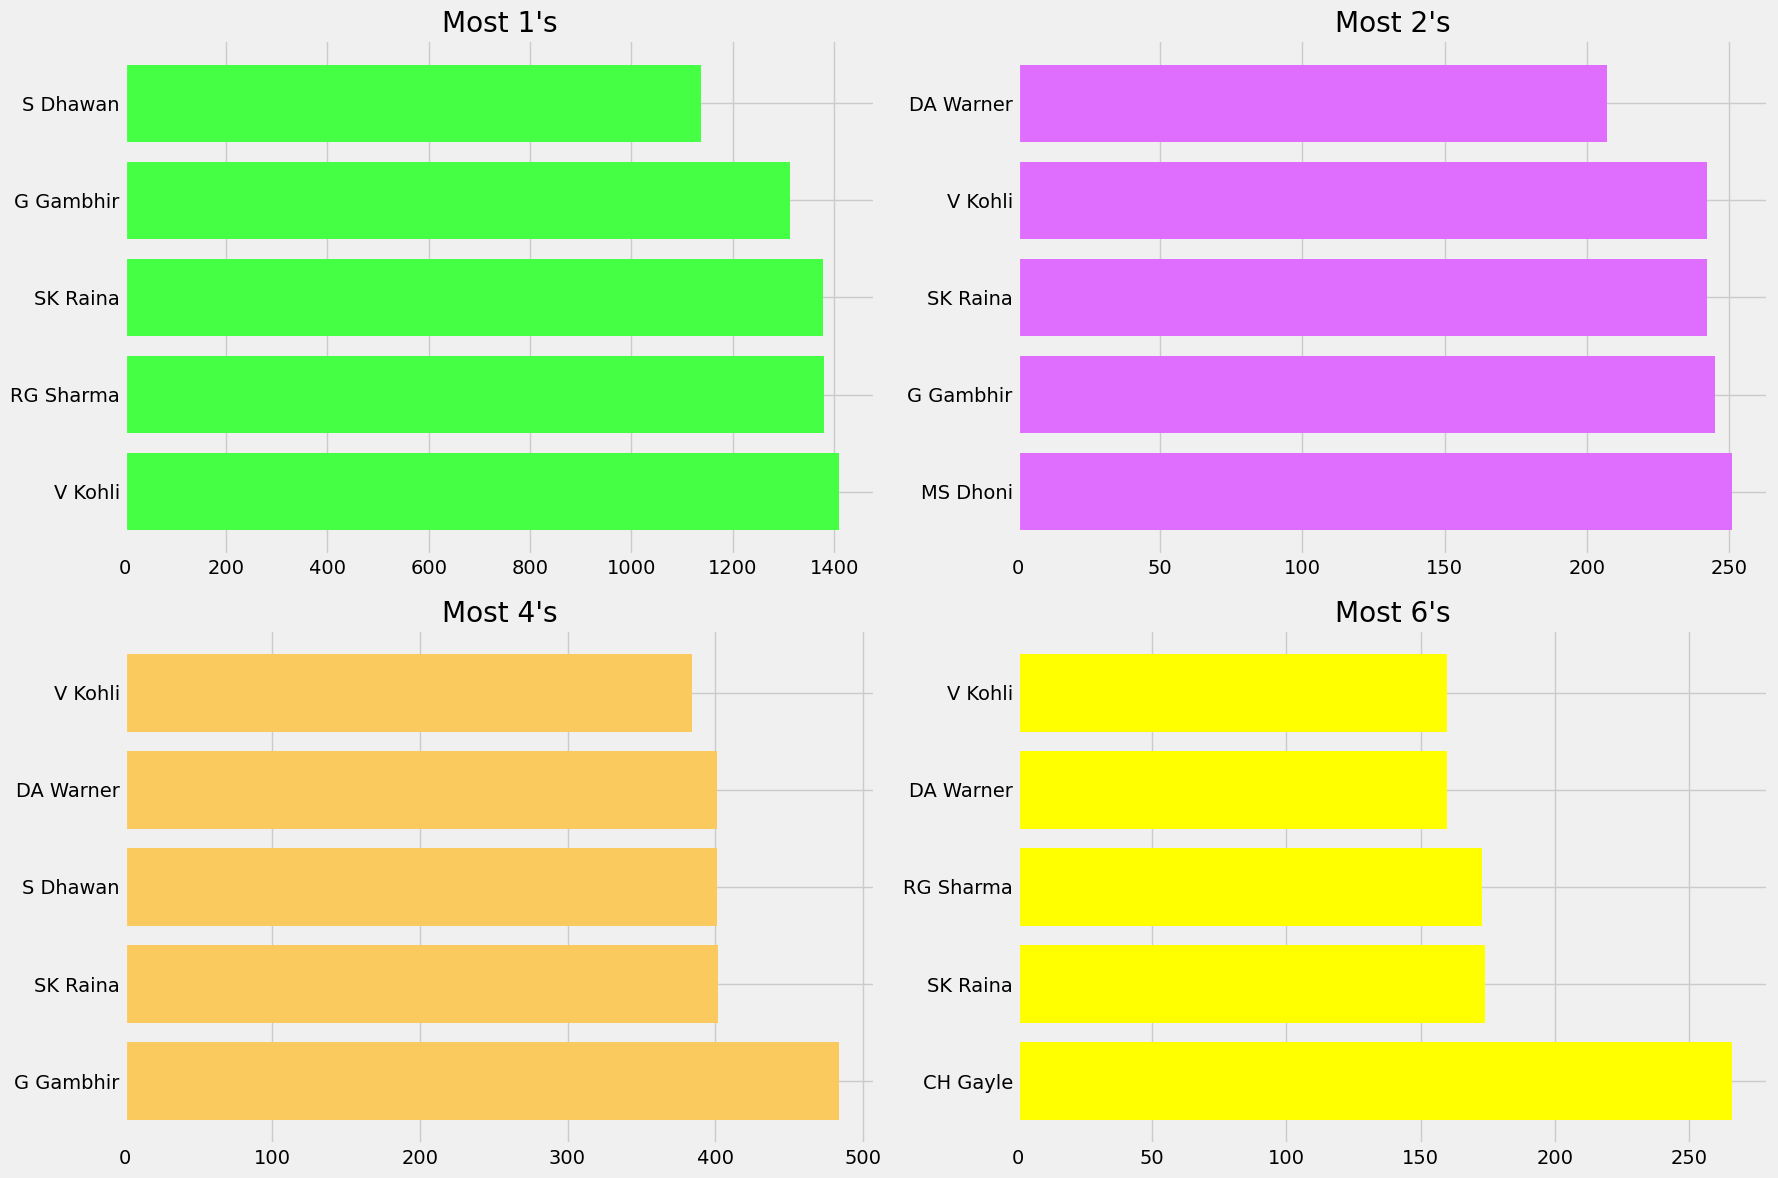

In [72]:
import matplotlib.pyplot as mlt

toppers = delivery.groupby(
    ['batsman', 'batsman_runs']
)['total_runs'].count().reset_index()

toppers = toppers.pivot_table(
    index='batsman',
    columns='batsman_runs',
    values='total_runs',
    fill_value=0
)

fig, ax = mlt.subplots(2, 2, figsize=(18, 12))

# Most 1s
toppers[1].sort_values(ascending=False)[:5].plot(
    kind='barh',
    ax=ax[0, 0],
    color='#45ff45',
    width=0.8
)
ax[0, 0].set_title("Most 1's")
ax[0, 0].set_ylabel("")

# Most 2s
toppers[2].sort_values(ascending=False)[:5].plot(
    kind='barh',
    ax=ax[0, 1],
    color='#df6dfd',
    width=0.8
)
ax[0, 1].set_title("Most 2's")
ax[0, 1].set_ylabel("")

# Most 4s
toppers[4].sort_values(ascending=False)[:5].plot(
    kind='barh',
    ax=ax[1, 0],
    color='#fbca5f',
    width=0.8
)
ax[1, 0].set_title("Most 4's")
ax[1, 0].set_ylabel("")

# Most 6s
toppers[6].sort_values(ascending=False)[:5].plot(
    kind='barh',
    ax=ax[1, 1],
    color='#ffff00',
    width=0.8
)
ax[1, 1].set_title("Most 6's")
ax[1, 1].set_ylabel("")

mlt.tight_layout()
mlt.show()

## Top Indivudual Scores

In [73]:
top_scores = delivery.groupby(['match_id', "batsman", 'batting_team'])['batsman_runs'].sum().reset_index()

top_scores.sort_values('batsman_runs', ascending = 0).head(10)

top_scores.nlargest(10, 'batsman_runs')

,match_id,batsman,batting_team,batsman_runs
6200,411,CH Gayle,RCB,175
900,60,BB McCullum,KKR,158
8426,562,AB de Villiers,RCB,133
9257,620,AB de Villiers,RCB,129
5585,372,CH Gayle,RCB,128
3135,206,M Vijay,CSK,127
529,36,DA Warner,SRH,126
7752,516,V Sehwag,KXIP,122
3686,243,PC Valthaty,KXIP,120
4223,279,V Sehwag,DD,119


## Indivual Scores by Top Batsman each Inning

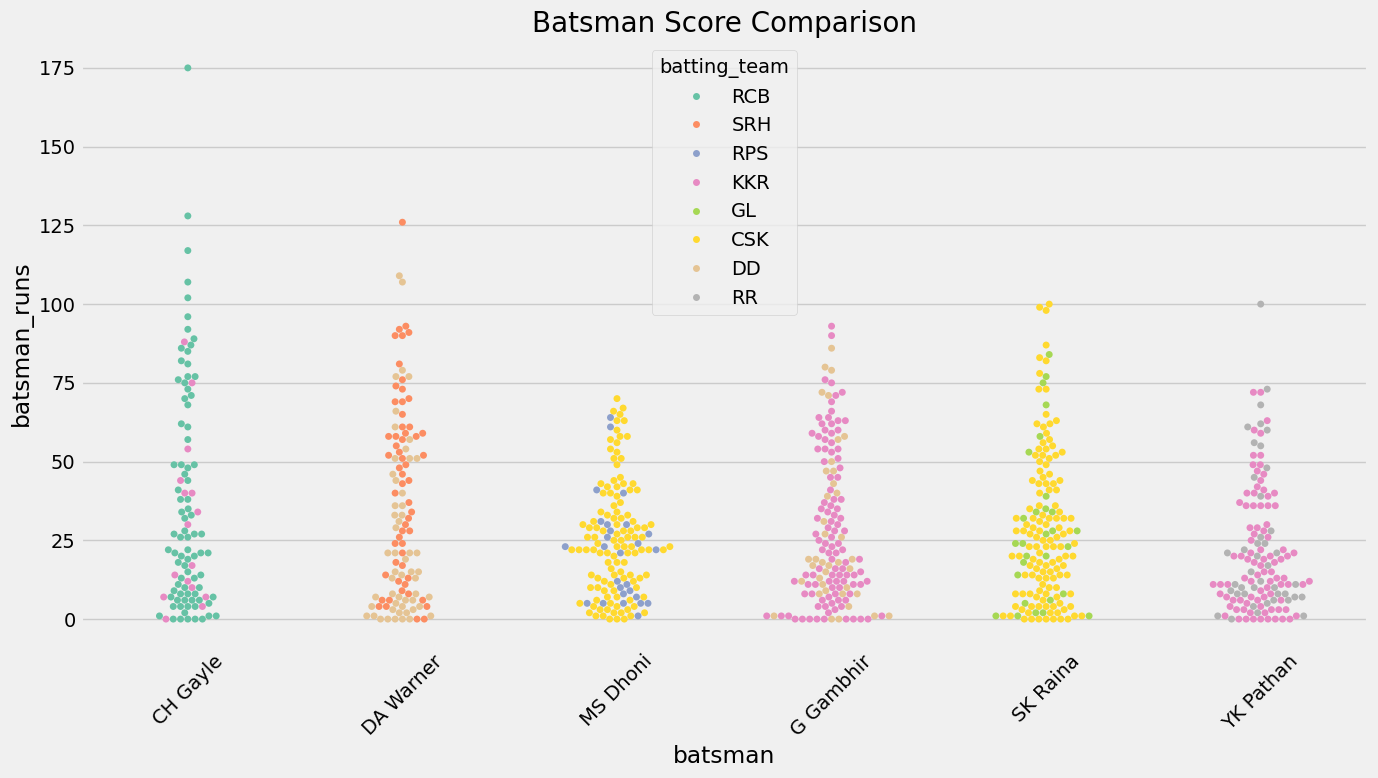

In [74]:
import seaborn as sns
import matplotlib.pyplot as mlt

swarm = [
    'CH Gayle',
    'V kohli',
    'G Gambhir',
    'SK Raina',
    'YK Pathan',
    'MS Dhoni',
    'AB de villiers',
    'DA Warner'
]

scores = delivery.groupby(
    ['match_id', 'batsman', 'batting_team']
)['batsman_runs'].sum().reset_index()

# Select only the required batsmen
scores = scores[scores['batsman'].isin(swarm)]

# Swarm plot
mlt.figure(figsize=(14, 8))

sns.swarmplot(
    x='batsman',
    y='batsman_runs',
    data=scores,
    hue='batting_team',
    palette='Set2'
)

mlt.xticks(rotation=45)
mlt.title("Batsman Score Comparison", fontsize=20)
mlt.tight_layout()
mlt.show()

## Runs Scored by Batsman Across Seasons


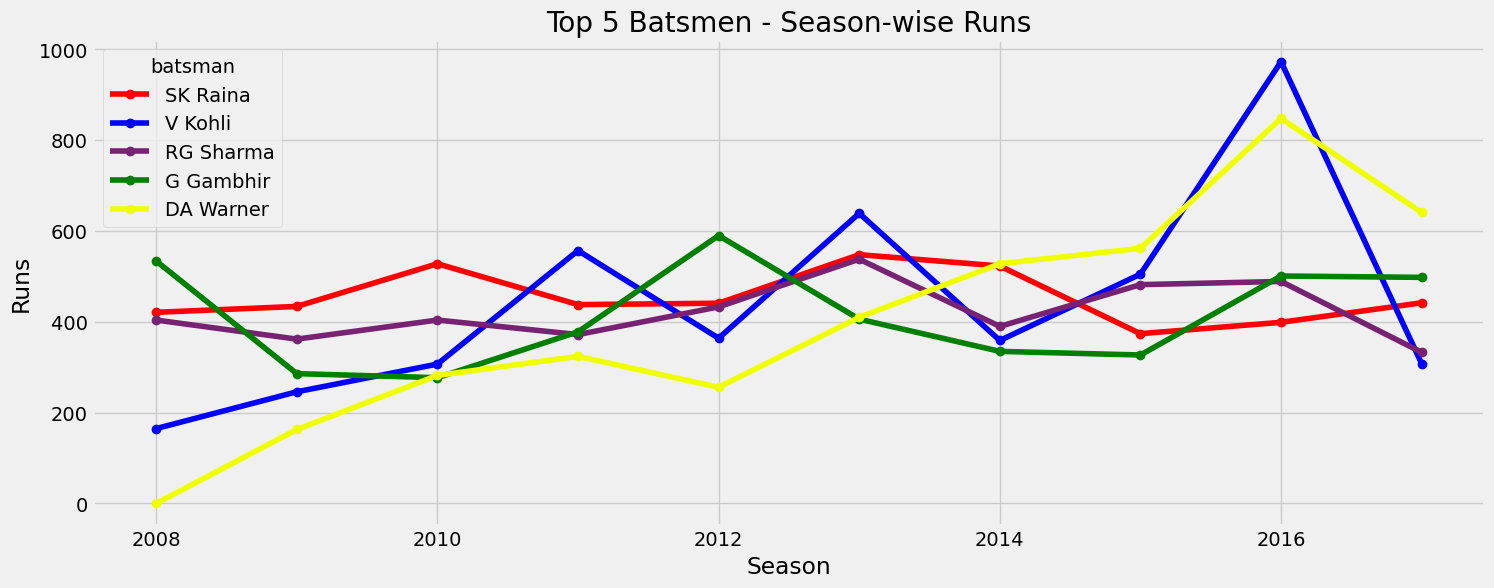

In [75]:
import matplotlib.pyplot as mlt

# Total runs by season and batsman
a = batsmen.groupby(
    ['season', 'batsman']
)['batsman_runs'].sum().reset_index()

# Convert seasons into columns
a = a.pivot(
    index='batsman',
    columns='season',
    values='batsman_runs'
).fillna(0)

# Calculate total runs across all seasons
a['Total'] = a.sum(axis=1)

# Select top 5 batsmen
a = a.sort_values(
    by='Total',
    ascending=False
).head(5)

# Remove Total column before plotting
a.drop('Total', axis=1, inplace=True)

# Plot
a.T.plot(
    color=['red', 'blue', '#772272', 'green', '#f0ff00'],
    marker='o'
)

fig = mlt.gcf()
fig.set_size_inches(16, 6)

mlt.xlabel("Season")
mlt.ylabel("Runs")
mlt.title("Top 5 Batsmen - Season-wise Runs")

mlt.show()

## Frequency of Scores

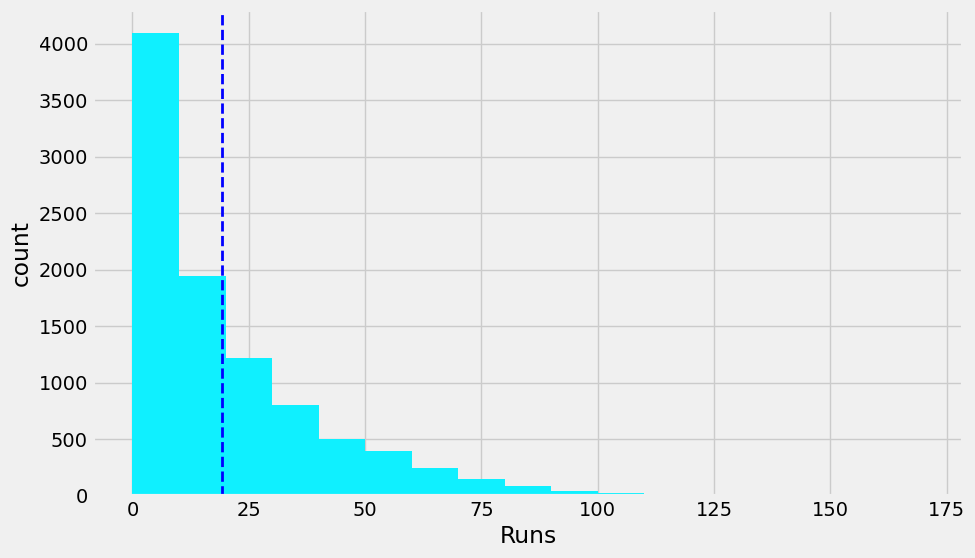

In [76]:
mlt.subplots(figsize = (10, 6))
bins = range(0, 180, 10)
mlt.hist(top_scores['batsman_runs'], bins, histtype = 'bar', rwidth = 1.2, color = '#0ff0ff')
mlt.xlabel('Runs')
mlt.ylabel('count')

mlt.axvline(top_scores['batsman_runs'].mean(), color = 'b', linestyle = 'dashed', linewidth = 2)
mlt.plot()
mlt.show()

## Orange Caps Each Season(Highest Run Getter Per Season)

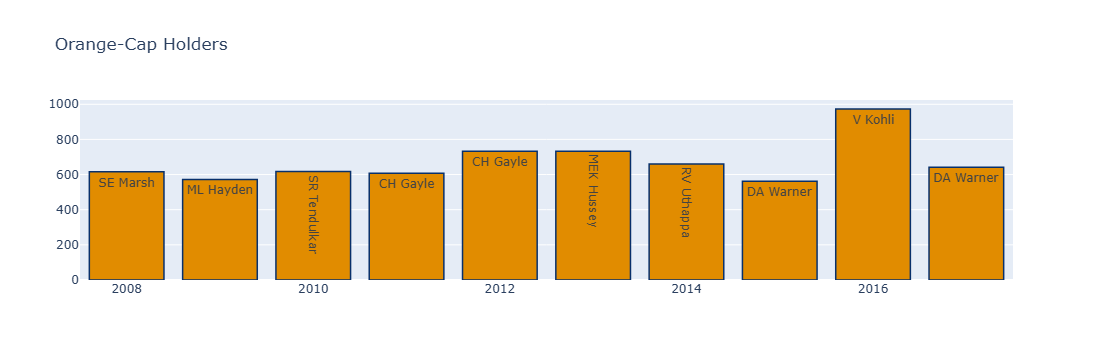

In [77]:
orange = matches[['id', 'season']]

orange = orange.merge(delivery, left_on = 'id', right_on = 'match_id', how = 'left')

orange = orange.groupby(['season', 'batsman'])['batsman_runs'].sum().reset_index()

orange = orange.sort_values('batsman_runs', ascending = 0)

orange = orange.drop_duplicates(subset = ['season'], keep = "first")

orange.sort_values(by = 'season')

trace1 = go.Bar(
x = orange['season'].values,
y = orange['batsman_runs'].values,
name = 'Total Matches', 
text = orange['batsman'].values,
marker = dict(
color = 'rgb(225, 140, 0)',
line = dict(
color = 'rgb(8, 48, 107)', 
width = 1.5,
)
),
opacity = 1
)

layout = go.Layout(
title = "Orange-Cap Holders",
)

data = [trace1]
fig = go.Figure(data = data, layout = layout)
py.iplot(fig, filename = 'stacked-bar')

## Top Bowlers

### Highest Wicket Taker

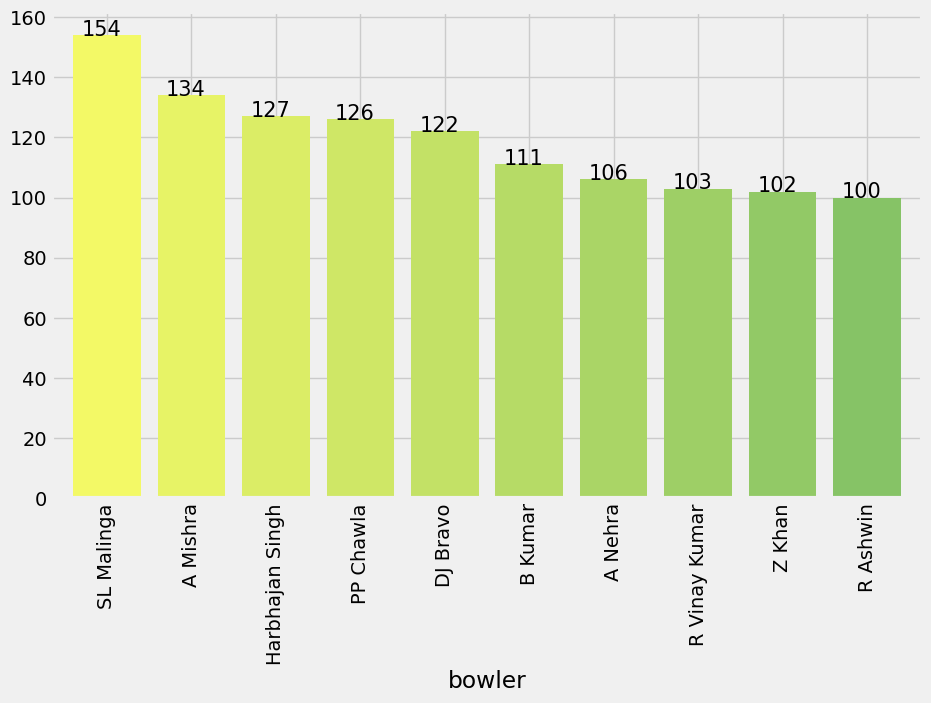

In [78]:
mlt.subplots(figsize = (10, 6))
dismissal_kinds = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
ct = delivery[delivery['dismissal_kind'].isin(dismissal_kinds)]

ax = ct['bowler'].value_counts()[:10].plot.bar(width = 0.8, color = sns.color_palette('summer_r', 20))

for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.10, p.get_height()), fontsize = 15)    
    
mlt.show()    

## Maximum Overs

In [79]:
eco = delivery.groupby(['bowler']).sum(numeric_only = True)
eco['total balls'] = delivery['bowler'].value_counts()
eco['overs'] = (eco['total balls']//6)
eco[eco['overs'] > 200].sort_values(by = 'overs', ascending = 0)['overs'].head(5).reset_index()

,bowler,overs
0,Harbhajan Singh,498
1,A Mishra,450
2,SL Malinga,449
3,P Kumar,439
4,PP Chawla,432


In [80]:
eco['economy'] = (eco['total_runs'] / (eco['overs']))

eco[eco['overs']>300].sort_values('economy')[:10].economy.reset_index().T

,0,1,2,3,4,5,6,7,8,9
bowler,SP Narine,R Ashwin,DW Steyn,SL Malinga,Harbhajan Singh,B Kumar,A Mishra,PP Ojha,Z Khan,P Kumar
economy,6.395706,6.493639,6.615599,6.757238,6.933735,7.046784,7.344444,7.404321,7.546174,7.612756


## Top 20 Bowlers

In [81]:
bowlers = delivery.groupby('bowler').sum(numeric_only = True).reset_index()

In [82]:
# 1. Bowler-wise runs given
bowlers = delivery.groupby('bowler')['total_runs'].sum().reset_index()
bowlers.rename(columns={'total_runs': 'runs_given'}, inplace=True)

# 2. Bowler-wise balls
bowl = delivery['bowler'].value_counts().reset_index()
bowl.columns = ['bowler', 'balls']

bowlers = bowlers.merge(bowl, on='bowler', how='left')

# 3. Dismissal types
dismissal_kinds = [
    'bowled',
    'caught',
    'lbw',
    'stumped',
    'caught and bowled',
    'hit wicket'
]

ct = delivery[delivery['dismissal_kind'].isin(dismissal_kinds)]

ct = ct['bowler'].value_counts().reset_index()
ct.columns = ['bowler', 'wickets']

# 4. Merge wickets
bowlers = bowlers.merge(ct, on='bowler', how='left')

# 5. No wickets = 0
bowlers['wickets'] = bowlers['wickets'].fillna(0)

# 6. Overs
bowlers['overs'] = bowlers['balls'] // 6

# 7. Economy
bowlers['economy'] = bowlers['runs_given'] * 6 / bowlers['balls']

# 8. Result
bowlers.head()

,bowler,runs_given,balls,wickets,overs,economy
0,A Ashish Reddy,400,270,18.0,45,8.888889
1,A Chandila,245,234,11.0,39,6.282051
2,A Choudhary,144,108,5.0,18,8.000000
3,A Flintoff,106,66,2.0,11,9.636364
4,A Kumble,1089,983,45.0,163,6.646999


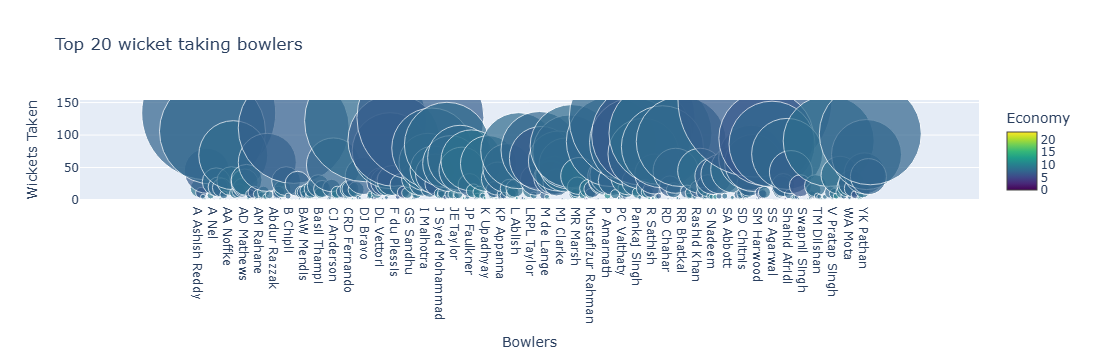

In [83]:
trace = go.Scatter(
    y=bowlers['wickets'],
    x=bowlers['bowler'],
    mode='markers',
    marker=dict(
        size=bowlers['wickets'].values,
        color=bowlers['economy'].values,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Economy')
    ),
    text=bowlers['overs'].values
)

data = [trace]

layout = go.Layout(
    autosize=True,
    title='Top 20 wicket taking bowlers',
    hovermode='closest',
    xaxis=dict(
        showgrid=False,
        zeroline=False,
        showline=False,
        title='Bowlers'
    ),
    yaxis=dict(
        title='Wickets Taken'
    ),
    showlegend=False
)

fig = go.Figure(data=data, layout=layout)

fig.show()

## Highest Dismissals For a Batsman by a Bowler


In [84]:
def get_top_bowler(batsman_name):
    batsman_data = delivery[delivery['batsman'] == batsman_name]
    batsman_data['dismissal_kind'].isin([
    'caught',
    'lbw',
    'stumped',
    'caught and bowled',
    'hit wicket'])
    top_bowler = batsman_data.groupby('bowler').count().sort_values(by = 'dismissal_kind', ascending = False).dismissal_kind[:1].reset_index()
    top_bowler['batsman'] = batsman_name
    return  top_bowler
    

In [85]:
batsman = ['CH Gayle', 'V kohli', 'SK Raina', 'AB de Villiers', 'MS Dhoni', 'G Gambhir', 'RG Sharma', 'RV Uthappa', 'S Dhawan', 'DA Warner']

In [86]:
results = [get_top_bowler(batsman) for batsman in batsman]

In [87]:
new = pd.concat(results, ignore_index = True)

In [88]:
new = new[['batsman', 'bowler', 'dismissal_kind']]
new.columns = ['batsman', 'bowler', 'No_of_Dismissals']

new.head()

,batsman,bowler,No_of_Dismissals
0,CH Gayle,P Kumar,93
1,SK Raina,Harbhajan Singh,125
2,AB de Villiers,RA Jadeja,74
3,MS Dhoni,PP Ojha,100
4,G Gambhir,Z Khan,85


## Purple Caps Each Season

In [89]:
dismissal_kinds = ["bowled", "caught", "lbw", "stumped", "hit wicket"]

purple = delivery.merge(
    matches,
    left_on='match_id',
    right_on='id',
    how='left'
)

purple = purple[
    purple['dismissal_kind'].isin(dismissal_kinds)
]

print(purple.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied',
       'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue',
       'umpire1', 'umpire2'],
      dtype='object')


In [90]:
purple = purple.groupby(
    ['season', 'bowler']
)['dismissal_kind'].count().reset_index()

In [91]:
purple = purple.sort_values('dismissal_kind', ascending = False)

In [92]:
purple = purple.drop_duplicates('season', keep = 'first').sort_values(by = 'season')

In [93]:
purple.rename({'dismissal_kind': 'count_wickets'}, axis = 1, inplace = True)

In [94]:
purple

,season,bowler,count_wickets
75,2008,Sohail Tanvir,22
152,2009,RP Singh,22
241,2010,PP Ojha,21
367,2011,SL Malinga,26
437,2012,M Morkel,25
509,2013,DJ Bravo,30
639,2014,MM Sharma,23
694,2015,DJ Bravo,25
773,2016,B Kumar,22
860,2017,B Kumar,25


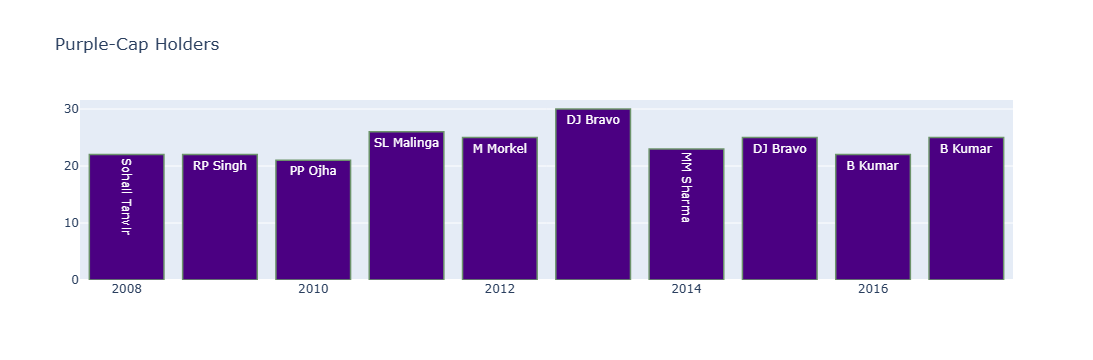

In [95]:
trace1 = go.Bar(
    x=purple['season'].values,
    y=purple['count_wickets'].values,
    name='Total Matches',
    text=purple['bowler'].values,
    marker=dict(
        color='rgb(75, 0, 130)',
        line=dict(
            color='rgb(108, 148, 107)',
            width=1.5
        )
    ),
    opacity=1
)

layout = go.Layout(
    title='Purple-Cap Holders'
)

data = [trace1]

fig = go.Figure(
    data=data,
    layout=layout
)

py.iplot(fig, filename='stacked-bar')